## Contextual Multi-armed Bandit    

As an example, we consider the contextual multi-armed bandit problem: predicting the optimal action of several options, where the cost of each action depends on contextual information.

Both the cost of each arm $\bold{z}$ and the contextual information are random variables

$\bold{x},\bold{z} \sim P$ 

We have $J$ bandits, and 2-dimensions of contextual info
$\bold{x} \in  \mathbb{R}^2$, $\bold{z} \in \mathbb{R}^J$

For each sample of contextual information, we need to choose one of J actions. This is represented by the decision variable $\bold{w}$. Because we can only choose one action, our decisions $\bold{w}$ are in the set of $J$-dimensional 1-hot vectors

$\bold{w} \in \{0,1\}^J, \sum_{j=1}^{J} w_j = 1$

To use our contextual information, we define a function $\bold{w}_{\theta}(\bold{x})$ parameterized by $\theta$ which maps from our input $\bold{x}$ to decision $\bold{w}$.

This makes the cost function of this decision problem:

$c(\bold{w}_{\theta}(\bold{x}),\bold{z}) = \bold{w}_{\theta}(\bold{x})^{\intercal} \bold{z}$

To estimate model parameters $\theta$, we minimize the expected cost over our training dataset
 
 $$\min_{\theta \in \Theta} \mathbb{E}_{(\bold{x},\bold{z}) \sim \mathcal{D}} \left[ c(\bold{w}_{\theta}(\bold{x}),\bold{z}) \right] = \frac{1}{n} \sum_{i=1}^{n} \bold{w}_\theta^\intercal \bold{z}$$

By estimating the model parameters while simultaneously optimizing the decision-making process, we obtain what is called the Integrated Estimation Objective (IEO).

$$\hat{\theta}^\text{IEO} = \inf_{\theta \in \Theta} \mathbb{E}_{(\bold{x},\bold{z}) \sim \mathcal{D}} \left[ c(\bold{w}_{\theta}(\bold{x}),\bold{z}) \right] =  \inf_{\theta \in \Theta} \frac{1}{n} \sum_{i=1}^{n} \bold{w}_\theta^\intercal \bold{z}$$

It is not always feasible to calculate this infimum using gradient descent techniques. Because $\bold{w}$ is one-hot, the derivative with respect to $\theta$ is 0 everyhwere except the transition between decisions. 

To get around this, we can replace the cost function with one of several differentiable surrogates. We consider the following options

### DPO

For a (stochastic) perturbed optimizer with noise $\boldsymbol{\xi}$ and temperature $\varepsilon>0$, define the (Monte‑Carlo) *soft* decision
$$
\hat{\pi}_\varepsilon(\boldsymbol{t})
\;\approx\;
\frac1{M}\sum_{m=1}^M \hat{\pi}(\boldsymbol{t}+\varepsilon \boldsymbol{\xi}^{(m)}),
\qquad
\hat{\pi}(\boldsymbol{t}) \in \arg\min_{\boldsymbol{w}\in\mathcal{W}} \boldsymbol{t}^\top \boldsymbol{w}.
$$

The IEO estimate under DPO is
$$
\hat{\theta}^{IEO}_{DPO}
\;\in\;
\arg\min_{\theta\in\Theta}\;
\frac1n \sum_{i=1}^n
\; \boldsymbol{z}_i^\top \hat{\pi}_\varepsilon\!\bigl(f_\theta(\boldsymbol{x}_i)\bigr).
$$


### SPO+

For linear objectives over a discrete feasible set $\mathcal{W}$, the SPO loss is
$$
\ell_{\mathrm{SPO}}(\boldsymbol{t},\boldsymbol{z})
=
\boldsymbol{z}^\top \hat{\pi}(\boldsymbol{t})-\min_{\boldsymbol{w}\in\mathcal{W}} \boldsymbol{z}^\top \boldsymbol{w}.
$$
The SPO+ surrogate is
$$
\ell_{\mathrm{SPO}^+}(\boldsymbol{t},\boldsymbol{z})
=
\max_{\boldsymbol{w}\in\mathcal{W}} (\boldsymbol{z}-2\boldsymbol{t})^\top \boldsymbol{w}
+2\boldsymbol{t}^\top \hat{\pi}(\boldsymbol{z})
-\boldsymbol{z}^\top \hat{\pi}(\boldsymbol{z}).
$$

The IEO estimate under SPO+ is
$$
\hat{\theta}^{IEO}_{SPO^+}
\;\in\;
\arg\min_{\theta\in\Theta}\;
\frac1n \sum_{i=1}^n
\ell_{\mathrm{SPO}^+}\!\bigl(f_\theta(\boldsymbol{x}_i),\boldsymbol{z}_i\bigr).
$$


### PG

Let $V(\boldsymbol{t})=\min_{\boldsymbol{w}\in\mathcal{W}} \boldsymbol{t}^\top \boldsymbol{w}$.
The downstream decision loss satisfies:
$$
\ell(\boldsymbol{t},\boldsymbol{z})=\boldsymbol{z}^\top \hat{\pi}(\boldsymbol{t}).
$$
The perturbation‑gradient (PG) losses are finite‑difference surrogates:
$$
\hat{\ell}^{\,b}_h(\boldsymbol{t},\boldsymbol{z})=\frac{V(\boldsymbol{t})-V(\boldsymbol{t}-h\boldsymbol{z})}{h},
\qquad
\hat{\ell}^{\,c}_h(\boldsymbol{t},\boldsymbol{z})=\frac{V(\boldsymbol{t}+h\boldsymbol{z})-V(\boldsymbol{t}-h\boldsymbol{z})}{2h}.
$$

The IEO estimate under PG (e.g., backward) is
$$
\hat{\theta}^{IEO}_{PG}
\;\in\;
\arg\min_{\theta\in\Theta}\;
\frac1n \sum_{i=1}^n
\hat{\ell}^{\,b}_h\!\bigl(f_\theta(\boldsymbol{x}_i),\boldsymbol{z}_i\bigr).
$$


We know that for well-specified models ($\exists \theta_0 \in \Theta s.t. P = P_{\theta_0}$), the regret of the decision induced by $\theta^{\text{IEO}}$ is vanishing as $n \rightarrow \infty$.

We also know that the quantity $\sqrt{n}(\hat{\theta}^{IEO} -\theta^*)$ is asympotically normal with 0 mean and a known covariance matrix. Here $\theta^*$ is the optimial model parameter.

Furthermore we know that a smaller covariance matrix implies that the regret of one decision stochastically dominates the regret of a decision induced by model parameters with a larger covariance matrix.

I would like to show a stochastic dominance relationship between $\hat{\theta}^{IEO}_{PG}, \hat{\theta}^{IEO}_{SPO+},\hat{\theta}^{IEO}_{DPO}$

This means we need to calculate the covariance matrices:

$$\Bigl( \nabla_{\theta\theta} v_0(\bold{w}_{\theta^*}) \Bigr)^{-1}
  \, \text{Cov}_P\!\bigl( \nabla_{\theta} c(\bold{w}_{\theta^*},\bold{z}) \bigr)
  \, \Bigl( \nabla_{\theta\theta} v_0(\bold{w}_{\theta^*}) \Bigr)^{-1}$$

VISUALIZING DECISION SPACES


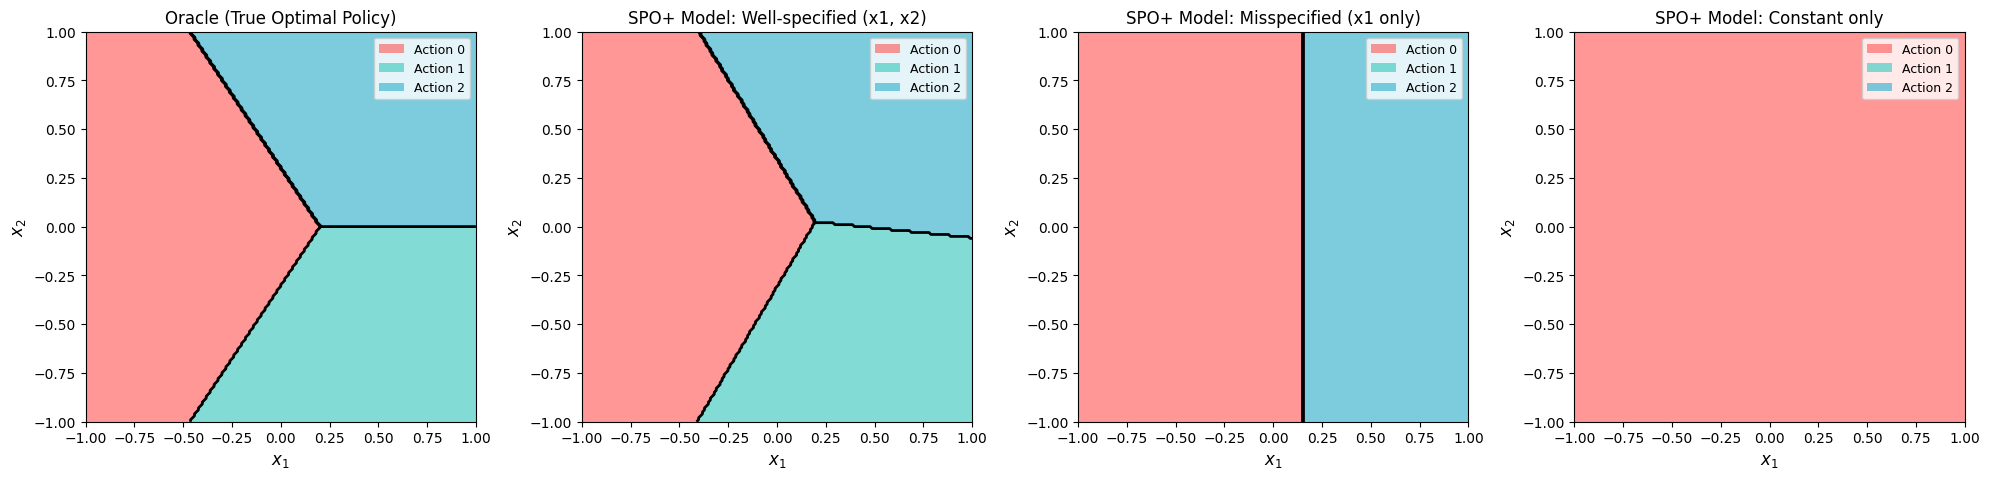


Key observations:
- Well-specified model (x1, x2) can recover all 3 decision regions
- Misspecified model (x1 only) can only make vertical decision boundaries
- Constant model picks one action for all contexts

CONVERGENCE EXPERIMENTS


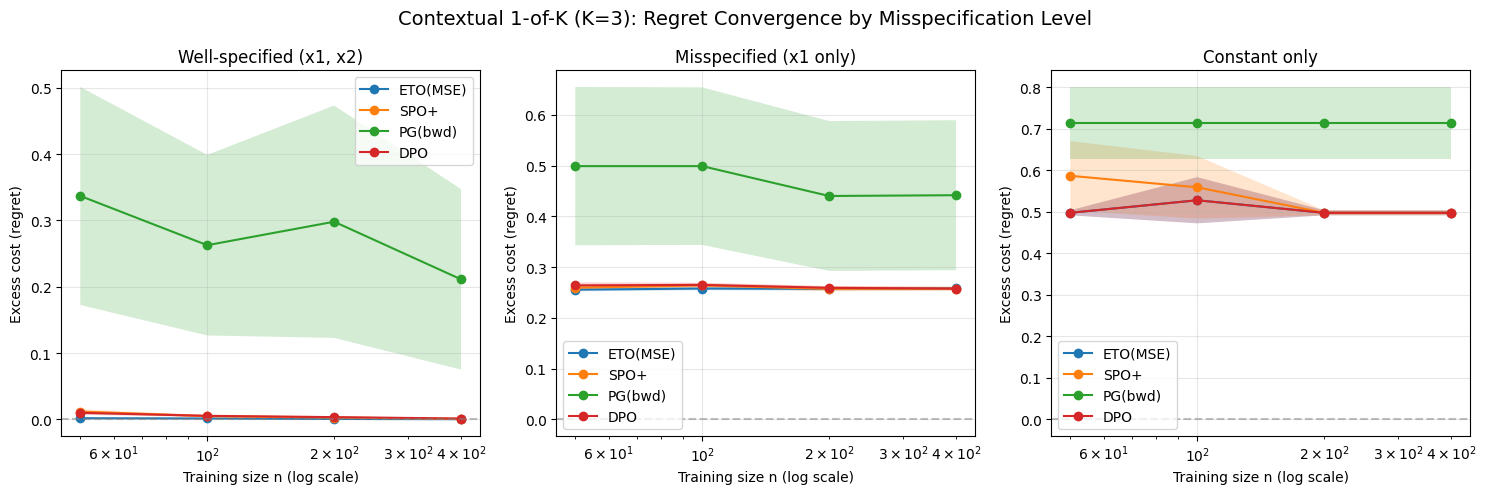


Done. Key insights:
- Well-specified: regret → 0 as n increases (all losses work)
- Misspecified (x1 only): bounded regret floor (cannot learn x2-dependent boundaries)
- Constant: large irreducible regret (picks same action regardless of context)


In [1]:
# --- Simplified Contextual 1-of-K decision problem + IEO experiments ---
# 2 features, 2 model parameters, K=3 decisions
# This cell is self-contained: defines the DGP, misspecification ladder, IEO losses, optimization, and evaluation.

import math
import numpy as np
import torch
from dataclasses import dataclass
from typing import Callable, Dict, List, Tuple
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

torch.set_default_dtype(torch.float64)
device = torch.device("cpu")

# -----------------------
# 1) Contextual 1-of-K setup (SIMPLIFIED: K=3, p=2, d_true=2)
# -----------------------
@dataclass
class BanditDGP:
    K: int = 3          # number of actions (3 decisions)
    p: int = 2          # context dimension (2 features)
    noise_std: float = 0.3
    seed: int = 0

    def __post_init__(self):
        rng = np.random.default_rng(self.seed)
        # True feature map is LINEAR: phi_true(x) = x (just the 2 input features)
        self.d_true = 2
        # True weights map phi_true -> cost vector in R^K
        # Hand-craft weights so each action is optimal in a distinct region
        # Action 0: best when x1 < 0
        # Action 1: best when x1 > 0 and x2 > 0
        # Action 2: best when x1 > 0 and x2 < 0
        self.W_true = np.array([
            [ 1.0,  0.0],   # Action 0: cost = x1
            [-0.5,  1.0],   # Action 1: cost = -0.5*x1 + x2
            [-0.5, -1.0],   # Action 2: cost = -0.5*x1 - x2
        ])
        self.b_true = np.array([0.0, 0.3, 0.3])  # small bias to shift boundaries

    def phi_true(self, x: np.ndarray) -> np.ndarray:
        # x shape (...,2) -> phi shape (...,2)
        # Linear feature map: just return x
        return x

    def f_star(self, x: np.ndarray) -> np.ndarray:
        # conditional mean of costs, shape (...,K)
        phi = self.phi_true(x)  # (..., d_true)
        return phi @ self.W_true.T + self.b_true

    def sample(self, n: int, rng: np.random.Generator) -> Tuple[np.ndarray, np.ndarray]:
        # contexts uniform on [-1,1]^p
        x = rng.uniform(-1.0, 1.0, size=(n, self.p))
        mean = self.f_star(x)
        z = mean + rng.normal(0.0, self.noise_std, size=mean.shape)
        return x, z

# decision: one-hot at argmin
def pi_hat(t: torch.Tensor) -> torch.Tensor:
    # t: (n,K) -> (n,K) one-hot
    idx = torch.argmin(t, dim=-1)
    return torch.nn.functional.one_hot(idx, num_classes=t.shape[-1]).to(t.dtype)

def V_of(t: torch.Tensor) -> torch.Tensor:
    # (n,K) -> (n,)
    return torch.min(t, dim=-1).values

# -----------------------
# 2) Misspecification ladder via feature maps
# -----------------------
def features_spec(level: int) -> Callable[[torch.Tensor], torch.Tensor]:
    # x: (n,2) -> phi: (n,d)
    # level 0: well-specified (linear features - matches true DGP)
    # level 1: misspecified (only x1 - missing x2)
    # level 2: severely misspecified (constant only)
    if level == 0:
        # Well-specified: uses both x1 and x2 (d=2)
        def phi(x):
            return x  # (n, 2)
        return phi
    if level == 1:
        # Misspecified: only uses x1 (d=1), cannot distinguish x2
        def phi(x):
            return x[:, 0:1]  # (n, 1)
        return phi
    if level == 2:
        # Severely misspecified: constant only (d=1)
        def phi(x):
            return torch.ones((x.shape[0], 1), dtype=x.dtype, device=x.device)
        return phi
    raise ValueError("level must be in {0,1,2}")

SPEC_NAMES = {0: "Well-specified (x1, x2)", 1: "Misspecified (x1 only)", 2: "Constant only"}

class LinearCostModel(torch.nn.Module):
    def __init__(self, K: int, phi: Callable[[torch.Tensor], torch.Tensor], d: int):
        super().__init__()
        self.K = K
        self.phi = phi
        self.W = torch.nn.Parameter(torch.zeros((K, d), dtype=torch.float64))
        self.b = torch.nn.Parameter(torch.zeros((K,), dtype=torch.float64))
        torch.nn.init.normal_(self.W, std=0.2)
        torch.nn.init.normal_(self.b, std=0.1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        Phi = self.phi(x)  # (n,d)
        return Phi @ self.W.T + self.b  # (n,K)

# -----------------------
# 3) Losses: ETO (MSE), SPO+, PG, DPO
# -----------------------
def loss_mse(t: torch.Tensor, z: torch.Tensor) -> torch.Tensor:
    return torch.mean((t - z)**2)

def loss_spoplus(t: torch.Tensor, z: torch.Tensor) -> torch.Tensor:
    term1 = torch.max(z - 2*t, dim=-1).values
    pi_z = pi_hat(z)
    term2 = 2.0 * torch.sum(t * pi_z, dim=-1)
    term3 = torch.sum(z * pi_z, dim=-1)
    return torch.mean(term1 + term2 - term3)

def loss_spoplus_smooth(t: torch.Tensor, z: torch.Tensor, tau: float = 0.25) -> torch.Tensor:
    term1 = tau * torch.logsumexp((z - 2.0*t) / tau, dim=-1)
    pi_z = pi_hat(z).to(t.dtype)
    term2 = 2.0 * torch.sum(t * pi_z, dim=-1)
    term3 = torch.sum(z * pi_z, dim=-1)
    return term1 + term2 - term3

SPO_TAU = 0.25

def loss_pg_backward(t: torch.Tensor, z: torch.Tensor, h: float = 0.25) -> torch.Tensor:
    return torch.mean((V_of(t) - V_of(t - h*z)) / h)

def loss_dpo_gumbel(t: torch.Tensor, z: torch.Tensor, eps: float = 0.5) -> torch.Tensor:
    p = torch.softmax(-t/eps, dim=-1)
    return torch.mean(torch.sum(z * p, dim=-1))

LOSS_FNS = {
    "ETO(MSE)": lambda t,z: loss_mse(t,z),
    "SPO+":     lambda t,z: loss_spoplus_smooth(t,z,tau=SPO_TAU).mean(),
    "PG(bwd)":  lambda t,z: loss_pg_backward(t,z,h=0.25),
    "DPO":      lambda t,z: loss_dpo_gumbel(t,z,eps=0.5),
}

# -----------------------
# 4) Training loop
# -----------------------
def fit_ieo(
    x_train: np.ndarray,
    z_train: np.ndarray,
    K: int,
    spec_level: int,
    loss_name: str,
    steps: int = 1000,
    lr: float = 2e-2,
    batch_size: int = 128,
    seed: int = 0,
) -> LinearCostModel:
    torch.manual_seed(seed)
    np_rng = np.random.default_rng(seed)

    x = torch.tensor(x_train, device=device)
    z = torch.tensor(z_train, device=device)

    phi = features_spec(spec_level)
    d = phi(x[:1]).shape[-1]
    model = LinearCostModel(K=K, phi=phi, d=d).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr)

    for step in range(steps):
        idx = np_rng.integers(0, x.shape[0], size=min(batch_size, x.shape[0]))
        xb = x[idx]
        zb = z[idx]
        tb = model(xb)
        global SPO_TAU
        if loss_name == "SPO+":
            tau_start, tau_end = 0.5, 0.05
            frac = step / max(1, steps - 1)
            SPO_TAU = tau_start * (tau_end / tau_start) ** frac

        loss = LOSS_FNS[loss_name](tb, zb)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

    return model

# -----------------------
# 5) Evaluation
# -----------------------
@torch.no_grad()
def evaluate_regret(
    dgp: BanditDGP,
    model: LinearCostModel,
    n_test: int = 10000,
    seed: int = 123,
) -> float:
    rng = np.random.default_rng(seed)
    x_te, z_te = dgp.sample(n_test, rng)

    x = torch.tensor(x_te, device=device)
    z = torch.tensor(z_te, device=device)

    t_hat = model(x)
    w_hat = pi_hat(t_hat)

    t_star = torch.tensor(dgp.f_star(x_te), device=device)
    w_star = pi_hat(t_star)

    cost_hat = torch.mean(torch.sum(z * w_hat, dim=-1)).item()
    cost_star = torch.mean(torch.sum(z * w_star, dim=-1)).item()
    return cost_hat - cost_star

# -----------------------
# 6) Visualize decision regions
# -----------------------
@torch.no_grad()
def plot_decision_regions(dgp: BanditDGP, model: LinearCostModel = None, title: str = "", ax=None):
    """Plot the decision regions (which action is chosen) over the 2D context space."""
    grid_res = 200
    x1 = np.linspace(-1, 1, grid_res)
    x2 = np.linspace(-1, 1, grid_res)
    X1, X2 = np.meshgrid(x1, x2)
    X_grid = np.stack([X1.ravel(), X2.ravel()], axis=-1)
    
    if model is None:
        # Oracle: use true costs
        costs = dgp.f_star(X_grid)
        decisions = np.argmin(costs, axis=-1)
    else:
        # Model predictions
        x_t = torch.tensor(X_grid, device=device)
        t_hat = model(x_t)
        decisions = torch.argmin(t_hat, dim=-1).cpu().numpy()
    
    decisions = decisions.reshape(grid_res, grid_res)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    
    cmap = ListedColormap(['#FF6B6B', '#4ECDC4', '#45B7D1'])  # Red, Teal, Blue
    im = ax.contourf(X1, X2, decisions, levels=[-0.5, 0.5, 1.5, 2.5], cmap=cmap, alpha=0.7)
    ax.contour(X1, X2, decisions, levels=[0.5, 1.5], colors='black', linewidths=2)
    ax.set_xlabel('$x_1$', fontsize=12)
    ax.set_ylabel('$x_2$', fontsize=12)
    ax.set_title(title, fontsize=12)
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_aspect('equal')
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#FF6B6B', alpha=0.7, label='Action 0'),
                       Patch(facecolor='#4ECDC4', alpha=0.7, label='Action 1'),
                       Patch(facecolor='#45B7D1', alpha=0.7, label='Action 2')]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
    
    return ax

# -----------------------
# 7) Run experiments
# -----------------------
dgp = BanditDGP(K=3, p=2, noise_std=0.3, seed=42)

# First, visualize the TRUE optimal decision regions
print("=" * 60)
print("VISUALIZING DECISION SPACES")
print("=" * 60)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Plot oracle (true optimal)
plot_decision_regions(dgp, model=None, title="Oracle (True Optimal Policy)", ax=axes[0])

# Train and plot models at different misspecification levels
n_train = 500
rng = np.random.default_rng(123)
x_tr, z_tr = dgp.sample(n_train, rng)

for i, spec in enumerate([0, 1, 2]):
    model = fit_ieo(x_tr, z_tr, K=dgp.K, spec_level=spec, loss_name="SPO+",
                    steps=1000, lr=2e-2, seed=42)
    plot_decision_regions(dgp, model=model, title=f"SPO+ Model: {SPEC_NAMES[spec]}", ax=axes[i+1])

plt.tight_layout()
plt.show()

print("\nKey observations:")
print("- Well-specified model (x1, x2) can recover all 3 decision regions")
print("- Misspecified model (x1 only) can only make vertical decision boundaries")
print("- Constant model picks one action for all contexts")

# -----------------------
# 8) Run convergence experiments
# -----------------------
print("\n" + "=" * 60)
print("CONVERGENCE EXPERIMENTS")
print("=" * 60)

ns = [50, 100, 200, 400]
spec_levels = [0, 1, 2]
n_trials = 10

results = {}

for spec in spec_levels:
    for loss_name in LOSS_FNS.keys():
        curve = []
        for n in ns:
            regrets = []
            for trial in range(n_trials):
                rng = np.random.default_rng(1000 + 17*trial + 100*spec + n)
                x_tr, z_tr = dgp.sample(n, rng)
                model = fit_ieo(
                    x_tr, z_tr, K=dgp.K, spec_level=spec, loss_name=loss_name,
                    steps=1000, lr=2e-2, batch_size=128,
                    seed=2000 + 19*trial + 10*spec
                )
                reg = evaluate_regret(dgp, model, n_test=5000, seed=5000 + trial)
                regrets.append(reg)
            curve.append((n, float(np.mean(regrets)), float(np.std(regrets))))
        results[(spec, loss_name)] = curve

# -----------------------
# 9) Plot: regret vs n for each misspec level
# -----------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, spec in enumerate(spec_levels):
    ax = axes[i]
    for loss_name in LOSS_FNS.keys():
        curve = results[(spec, loss_name)]
        n_arr = np.array([c[0] for c in curve])
        mean = np.array([c[1] for c in curve])
        std = np.array([c[2] for c in curve])
        ax.plot(n_arr, mean, marker='o', label=loss_name)
        ax.fill_between(n_arr, mean - 1.96*std/np.sqrt(n_trials), 
                        mean + 1.96*std/np.sqrt(n_trials), alpha=0.2)
    ax.set_xscale("log")
    ax.axhline(0.0, linestyle="--", color='gray', alpha=0.5)
    ax.set_xlabel("Training size n (log scale)")
    ax.set_ylabel("Excess cost (regret)")
    ax.set_title(f"{SPEC_NAMES[spec]}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Contextual 1-of-K (K=3): Regret Convergence by Misspecification Level", fontsize=14)
plt.tight_layout()
plt.show()

print("\nDone. Key insights:")
print("- Well-specified: regret → 0 as n increases (all losses work)")
print("- Misspecified (x1 only): bounded regret floor (cannot learn x2-dependent boundaries)")
print("- Constant: large irreducible regret (picks same action regardless of context)")


ASYMPTOTIC CONVERGENCE ANALYSIS
Training oracle model with large n to approximate theta*...
theta* shape: (9,) (W: torch.Size([3, 2]), b: torch.Size([3]))
Running 100 trials for n=50...
Running 100 trials for n=100...
Running 100 trials for n=200...
Running 100 trials for n=400...


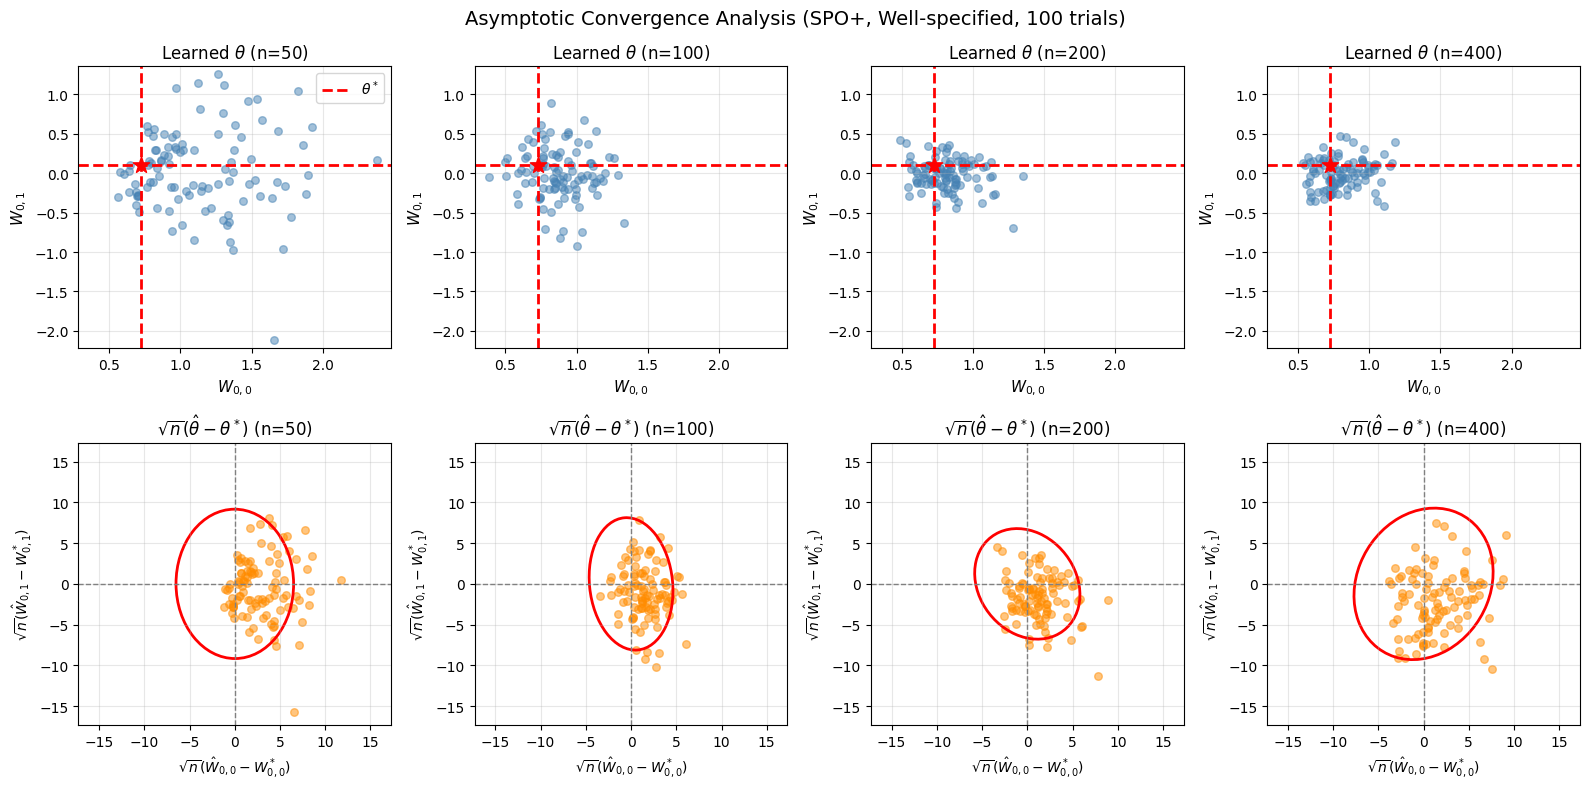

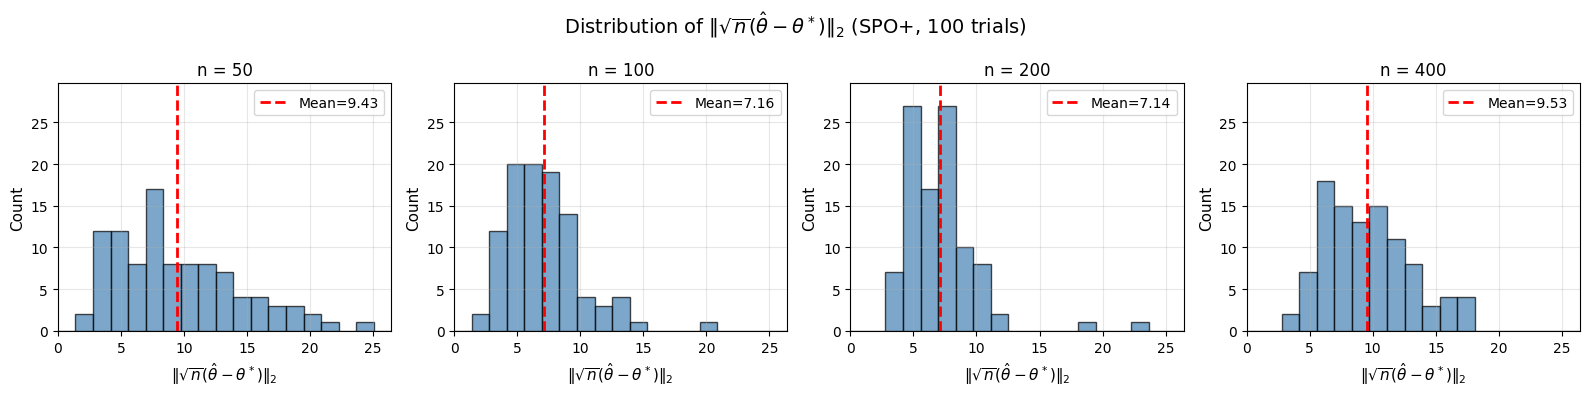

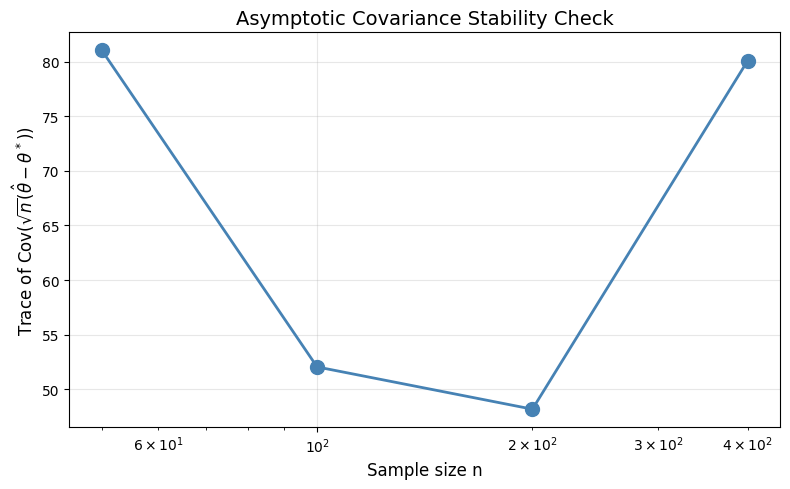


Key observations:
- As n increases, the cloud of learned θ shrinks toward θ*
- The sqrt(n)-scaled differences should have roughly constant variance (asymptotic normality)
- The 95% confidence ellipses show the asymptotic covariance structure


In [2]:
# -----------------------
# 10) Asymptotic Convergence Analysis
# -----------------------
# Plot sqrt(n)(theta_learned - theta_optimal) distribution across trials
# and the distribution of learned thetas in 2D parameter space

print("\n" + "=" * 60)
print("ASYMPTOTIC CONVERGENCE ANALYSIS")
print("=" * 60)

# First, we need theta_optimal: train with very large n to approximate
print("Training oracle model with large n to approximate theta*...")
n_oracle = 10000
rng_oracle = np.random.default_rng(999)
x_oracle, z_oracle = dgp.sample(n_oracle, rng_oracle)
model_oracle = fit_ieo(x_oracle, z_oracle, K=dgp.K, spec_level=0, loss_name="SPO+",
                       steps=2000, lr=1e-2, seed=999)

# Extract theta* (flatten W and b into a single vector)
with torch.no_grad():
    theta_star = torch.cat([model_oracle.W.flatten(), model_oracle.b]).cpu().numpy()
print(f"theta* shape: {theta_star.shape} (W: {model_oracle.W.shape}, b: {model_oracle.b.shape})")

# Run trials for each sample size
ns_analysis = [50, 100, 200, 400]
n_trials_analysis = 100  # Increased to 100 trials
loss_name_analysis = "SPO+"

# Store results: dict of n -> list of theta vectors
theta_learned_by_n = {n: [] for n in ns_analysis}
sqrt_n_diff_by_n = {n: [] for n in ns_analysis}

for n in ns_analysis:
    print(f"Running {n_trials_analysis} trials for n={n}...")
    for trial in range(n_trials_analysis):
        rng = np.random.default_rng(3000 + 31*trial + n)
        x_tr, z_tr = dgp.sample(n, rng)
        model = fit_ieo(x_tr, z_tr, K=dgp.K, spec_level=0, loss_name=loss_name_analysis,
                        steps=1000, lr=2e-2, seed=4000 + 37*trial + n)
        
        with torch.no_grad():
            theta_hat = torch.cat([model.W.flatten(), model.b]).cpu().numpy()
        
        theta_learned_by_n[n].append(theta_hat)
        sqrt_n_diff = np.sqrt(n) * (theta_hat - theta_star)
        sqrt_n_diff_by_n[n].append(sqrt_n_diff)

# Convert to arrays
for n in ns_analysis:
    theta_learned_by_n[n] = np.array(theta_learned_by_n[n])
    sqrt_n_diff_by_n[n] = np.array(sqrt_n_diff_by_n[n])

# -----------------------
# Compute shared axis limits for consistent scaling
# -----------------------
param_idx1, param_idx2 = 0, 1  # W[0,0] and W[0,1]

# Learned theta limits (top row)
all_theta_p1 = np.concatenate([theta_learned_by_n[n][:, param_idx1] for n in ns_analysis])
all_theta_p2 = np.concatenate([theta_learned_by_n[n][:, param_idx2] for n in ns_analysis])
theta_xlim = (min(all_theta_p1.min(), theta_star[param_idx1]) - 0.1, 
              max(all_theta_p1.max(), theta_star[param_idx1]) + 0.1)
theta_ylim = (min(all_theta_p2.min(), theta_star[param_idx2]) - 0.1, 
              max(all_theta_p2.max(), theta_star[param_idx2]) + 0.1)

# sqrt(n) diff limits (bottom row)
all_diff_p1 = np.concatenate([sqrt_n_diff_by_n[n][:, param_idx1] for n in ns_analysis])
all_diff_p2 = np.concatenate([sqrt_n_diff_by_n[n][:, param_idx2] for n in ns_analysis])
diff_max = max(np.abs(all_diff_p1).max(), np.abs(all_diff_p2).max()) * 1.1
diff_lim = (-diff_max, diff_max)

# Histogram limits
all_norms = np.concatenate([np.linalg.norm(sqrt_n_diff_by_n[n], axis=1) for n in ns_analysis])
hist_xlim = (0, all_norms.max() * 1.1)
hist_ylim = (0, None)  # Will be set after computing histograms

# -----------------------
# Plot 1: Distribution of learned thetas in 2D (first 2 W parameters)
# -----------------------
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

param_names = ['$W_{0,0}$', '$W_{0,1}$']

# Top row: learned theta distribution (first 2 params)
for i, n in enumerate(ns_analysis):
    ax = axes[0, i]
    thetas = theta_learned_by_n[n]
    ax.scatter(thetas[:, param_idx1], thetas[:, param_idx2], alpha=0.5, s=30, c='steelblue')
    ax.axvline(theta_star[param_idx1], color='red', linestyle='--', linewidth=2, label='$\\theta^*$')
    ax.axhline(theta_star[param_idx2], color='red', linestyle='--', linewidth=2)
    ax.scatter([theta_star[param_idx1]], [theta_star[param_idx2]], color='red', s=150, marker='*', zorder=5)
    ax.set_xlabel(param_names[0], fontsize=11)
    ax.set_ylabel(param_names[1], fontsize=11)
    ax.set_title(f'Learned $\\theta$ (n={n})', fontsize=12)
    ax.set_xlim(theta_xlim)
    ax.set_ylim(theta_ylim)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(loc='upper right')

# Bottom row: sqrt(n)(theta - theta*) distribution (first 2 params)
from matplotlib.patches import Ellipse
for i, n in enumerate(ns_analysis):
    ax = axes[1, i]
    diffs = sqrt_n_diff_by_n[n]
    ax.scatter(diffs[:, param_idx1], diffs[:, param_idx2], alpha=0.5, s=30, c='darkorange')
    ax.axvline(0, color='gray', linestyle='--', linewidth=1)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel(f'$\\sqrt{{n}}(\\hat{{W}}_{{0,0}} - W^*_{{0,0}})$', fontsize=10)
    ax.set_ylabel(f'$\\sqrt{{n}}(\\hat{{W}}_{{0,1}} - W^*_{{0,1}})$', fontsize=10)
    ax.set_title(f'$\\sqrt{{n}}(\\hat{{\\theta}} - \\theta^*)$ (n={n})', fontsize=12)
    ax.set_xlim(diff_lim)
    ax.set_ylim(diff_lim)
    ax.grid(True, alpha=0.3)
    
    # Add 95% confidence ellipse
    cov = np.cov(diffs[:, param_idx1], diffs[:, param_idx2])
    eigenvalues, eigenvectors = np.linalg.eig(cov)
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    width, height = 2 * np.sqrt(5.991 * eigenvalues)  # 95% chi-squared with 2 dof
    ellipse = Ellipse(xy=(0, 0), width=width, height=height, angle=angle,
                      edgecolor='red', facecolor='none', linewidth=2, linestyle='-')
    ax.add_patch(ellipse)

plt.suptitle(f'Asymptotic Convergence Analysis ({loss_name_analysis}, Well-specified, {n_trials_analysis} trials)', fontsize=14)
plt.tight_layout()
plt.show()

# -----------------------
# Plot 2: Histogram of sqrt(n)(theta - theta*) L2 norm
# -----------------------
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# First pass: compute histograms to find max y
max_count = 0
hist_data = {}
bins = np.linspace(hist_xlim[0], hist_xlim[1], 20)
for n in ns_analysis:
    diffs = sqrt_n_diff_by_n[n]
    norms = np.linalg.norm(diffs, axis=1)
    counts, _ = np.histogram(norms, bins=bins)
    max_count = max(max_count, counts.max())
    hist_data[n] = norms

# Second pass: plot with consistent axes
for i, n in enumerate(ns_analysis):
    ax = axes[i]
    norms = hist_data[n]
    
    ax.hist(norms, bins=bins, alpha=0.7, color='steelblue', edgecolor='black')
    ax.axvline(np.mean(norms), color='red', linestyle='--', linewidth=2, label=f'Mean={np.mean(norms):.2f}')
    ax.set_xlabel('$\\|\\sqrt{n}(\\hat{\\theta} - \\theta^*)\\|_2$', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'n = {n}', fontsize=12)
    ax.set_xlim(hist_xlim)
    ax.set_ylim(0, max_count * 1.1)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Distribution of $\\|\\sqrt{{n}}(\\hat{{\\theta}} - \\theta^*)\\|_2$ ({loss_name_analysis}, {n_trials_analysis} trials)', fontsize=14)
plt.tight_layout()
plt.show()

# -----------------------
# Plot 3: Compare sqrt(n) scaling across sample sizes
# -----------------------
fig, ax = plt.subplots(figsize=(8, 5))

# For each n, compute the covariance of sqrt(n)(theta - theta*)
cov_traces = []
for n in ns_analysis:
    diffs = sqrt_n_diff_by_n[n]
    cov = np.cov(diffs.T)
    cov_traces.append(np.trace(cov))

ax.plot(ns_analysis, cov_traces, 'o-', markersize=10, linewidth=2, color='steelblue')
ax.set_xlabel('Sample size n', fontsize=12)
ax.set_ylabel('Trace of Cov($\\sqrt{n}(\\hat{\\theta} - \\theta^*)$)', fontsize=12)
ax.set_title('Asymptotic Covariance Stability Check', fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_xscale('log')

plt.tight_layout()
plt.show()

print("\nKey observations:")
print("- As n increases, the cloud of learned θ shrinks toward θ*")
print("- The sqrt(n)-scaled differences should have roughly constant variance (asymptotic normality)")
print("- The 95% confidence ellipses show the asymptotic covariance structure")


QUADRATIC DGP SETTING
Visualizing decision spaces for Quadratic DGP...


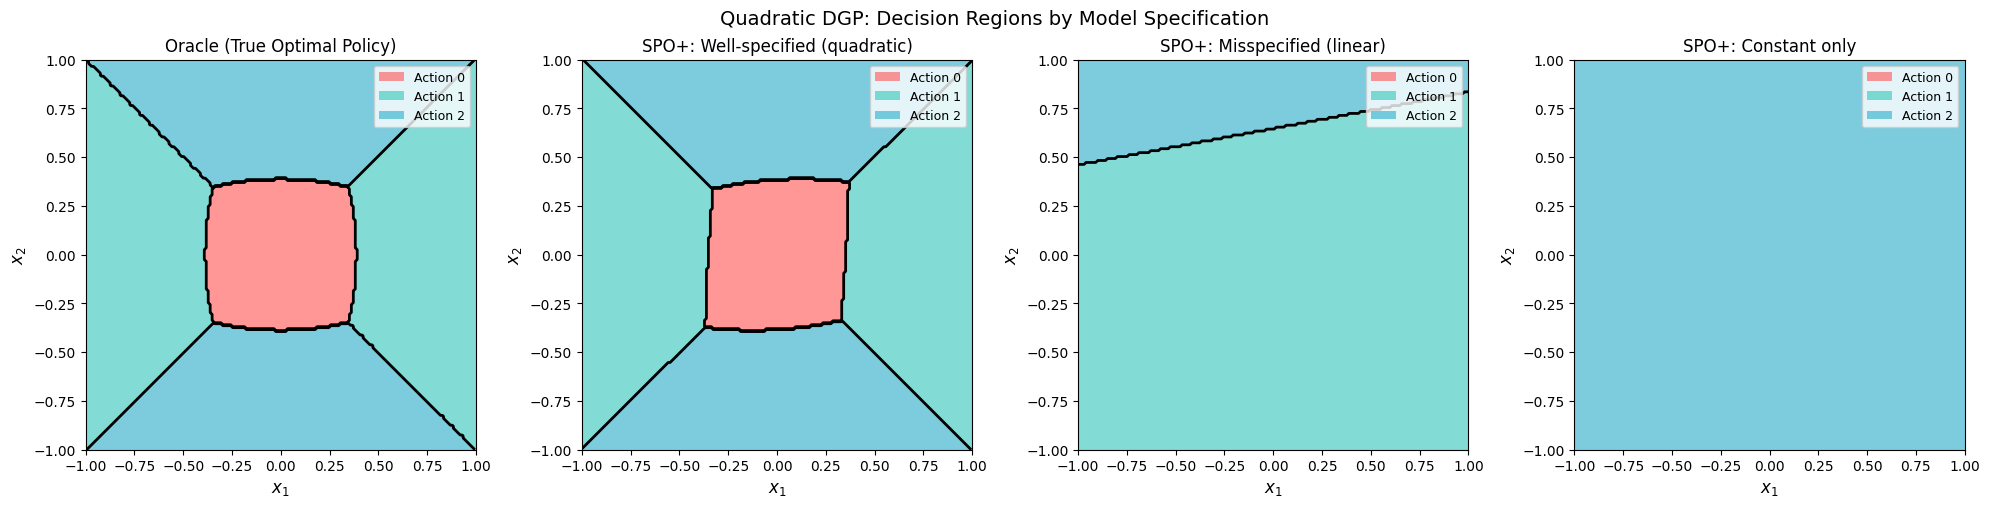


Key observations for Quadratic DGP:
- Oracle has curved (parabolic) decision boundaries
- Well-specified quadratic model can approximate these curves
- Linear model can only make straight-line boundaries
- Constant model picks one action for all contexts


In [3]:
# -----------------------
# 11) QUADRATIC DGP SETTING
# -----------------------
# True model: quadratic features (x1^2, x2^2, x1*x2) with K=3 decisions
# Misspecification levels: quadratic (well-specified), linear, constant

print("\n" + "=" * 60)
print("QUADRATIC DGP SETTING")
print("=" * 60)

@dataclass
class QuadraticBanditDGP:
    """DGP where true cost depends on quadratic features of x."""
    K: int = 3          # number of actions
    p: int = 2          # context dimension (2 features)
    noise_std: float = 0.3
    seed: int = 0

    def __post_init__(self):
        rng = np.random.default_rng(self.seed)
        # True feature map is QUADRATIC: phi_true(x) = [x1^2, x2^2, x1*x2]
        self.d_true = 3
        # Hand-craft weights so each action is optimal in a distinct region
        # Action 0: best near origin (low x1^2 + x2^2)
        # Action 1: best when x1^2 is large (corners along x1 axis)
        # Action 2: best when x2^2 is large (corners along x2 axis)
        self.W_true = np.array([
            [ 1.0,  1.0,  0.0],   # Action 0: cost = x1^2 + x2^2 (high at corners)
            [-1.0,  0.5,  0.0],   # Action 1: cost = -x1^2 + 0.5*x2^2 (low when |x1| large)
            [ 0.5, -1.0,  0.0],   # Action 2: cost = 0.5*x1^2 - x2^2 (low when |x2| large)
        ])
        self.b_true = np.array([0.0, 0.3, 0.3])

    def phi_true(self, x: np.ndarray) -> np.ndarray:
        # x shape (...,2) -> phi shape (...,3)
        x1 = x[..., 0]
        x2 = x[..., 1]
        return np.stack([x1**2, x2**2, x1*x2], axis=-1)

    def f_star(self, x: np.ndarray) -> np.ndarray:
        phi = self.phi_true(x)
        return phi @ self.W_true.T + self.b_true

    def sample(self, n: int, rng: np.random.Generator) -> Tuple[np.ndarray, np.ndarray]:
        x = rng.uniform(-1.0, 1.0, size=(n, self.p))
        mean = self.f_star(x)
        z = mean + rng.normal(0.0, self.noise_std, size=mean.shape)
        return x, z

# Feature maps for quadratic DGP
def features_spec_quad(level: int) -> Callable[[torch.Tensor], torch.Tensor]:
    # level 0: well-specified (quadratic features)
    # level 1: misspecified (linear only)
    # level 2: severely misspecified (constant only)
    if level == 0:
        # Well-specified: quadratic features (d=3)
        def phi(x):
            x1, x2 = x[:, 0], x[:, 1]
            return torch.stack([x1**2, x2**2, x1*x2], dim=-1)
        return phi
    if level == 1:
        # Misspecified: linear features only (d=2)
        def phi(x):
            return x  # (n, 2)
        return phi
    if level == 2:
        # Severely misspecified: constant only (d=1)
        def phi(x):
            return torch.ones((x.shape[0], 1), dtype=x.dtype, device=x.device)
        return phi
    raise ValueError("level must be in {0,1,2}")

SPEC_NAMES_QUAD = {0: "Well-specified (quadratic)", 1: "Misspecified (linear)", 2: "Constant only"}

# Create quadratic DGP
dgp_quad = QuadraticBanditDGP(K=3, p=2, noise_std=0.3, seed=42)

# -----------------------
# Visualize decision regions for quadratic DGP
# -----------------------
print("Visualizing decision spaces for Quadratic DGP...")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Plot oracle (true optimal)
plot_decision_regions(dgp_quad, model=None, title="Oracle (True Optimal Policy)", ax=axes[0])

# Custom fit function for quadratic features
def fit_ieo_quad(
    x_train: np.ndarray,
    z_train: np.ndarray,
    K: int,
    spec_level: int,
    loss_name: str,
    steps: int = 1000,
    lr: float = 2e-2,
    batch_size: int = 128,
    seed: int = 0,
) -> LinearCostModel:
    torch.manual_seed(seed)
    np_rng = np.random.default_rng(seed)

    x = torch.tensor(x_train, device=device)
    z = torch.tensor(z_train, device=device)

    phi = features_spec_quad(spec_level)
    d = phi(x[:1]).shape[-1]
    model = LinearCostModel(K=K, phi=phi, d=d).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr)

    for step in range(steps):
        idx = np_rng.integers(0, x.shape[0], size=min(batch_size, x.shape[0]))
        xb = x[idx]
        zb = z[idx]
        tb = model(xb)
        global SPO_TAU
        if loss_name == "SPO+":
            tau_start, tau_end = 0.5, 0.05
            frac = step / max(1, steps - 1)
            SPO_TAU = tau_start * (tau_end / tau_start) ** frac

        loss = LOSS_FNS[loss_name](tb, zb)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

    return model

# Train and plot models at different misspecification levels
n_train = 500
rng = np.random.default_rng(123)
x_tr_q, z_tr_q = dgp_quad.sample(n_train, rng)

for i, spec in enumerate([0, 1, 2]):
    model = fit_ieo_quad(x_tr_q, z_tr_q, K=dgp_quad.K, spec_level=spec, loss_name="SPO+",
                         steps=1000, lr=2e-2, seed=42)
    plot_decision_regions(dgp_quad, model=model, title=f"SPO+: {SPEC_NAMES_QUAD[spec]}", ax=axes[i+1])

plt.suptitle("Quadratic DGP: Decision Regions by Model Specification", fontsize=14)
plt.tight_layout()
plt.show()

print("\nKey observations for Quadratic DGP:")
print("- Oracle has curved (parabolic) decision boundaries")
print("- Well-specified quadratic model can approximate these curves")
print("- Linear model can only make straight-line boundaries")
print("- Constant model picks one action for all contexts")


REGRET CONVERGENCE: QUADRATIC DGP
Running: spec=0 (Well-specified (quadratic)), loss=ETO(MSE)...
Running: spec=0 (Well-specified (quadratic)), loss=SPO+...
Running: spec=0 (Well-specified (quadratic)), loss=PG(bwd)...
Running: spec=0 (Well-specified (quadratic)), loss=DPO...
Running: spec=1 (Misspecified (linear)), loss=ETO(MSE)...
Running: spec=1 (Misspecified (linear)), loss=SPO+...
Running: spec=1 (Misspecified (linear)), loss=PG(bwd)...
Running: spec=1 (Misspecified (linear)), loss=DPO...
Running: spec=2 (Constant only), loss=ETO(MSE)...
Running: spec=2 (Constant only), loss=SPO+...
Running: spec=2 (Constant only), loss=PG(bwd)...
Running: spec=2 (Constant only), loss=DPO...


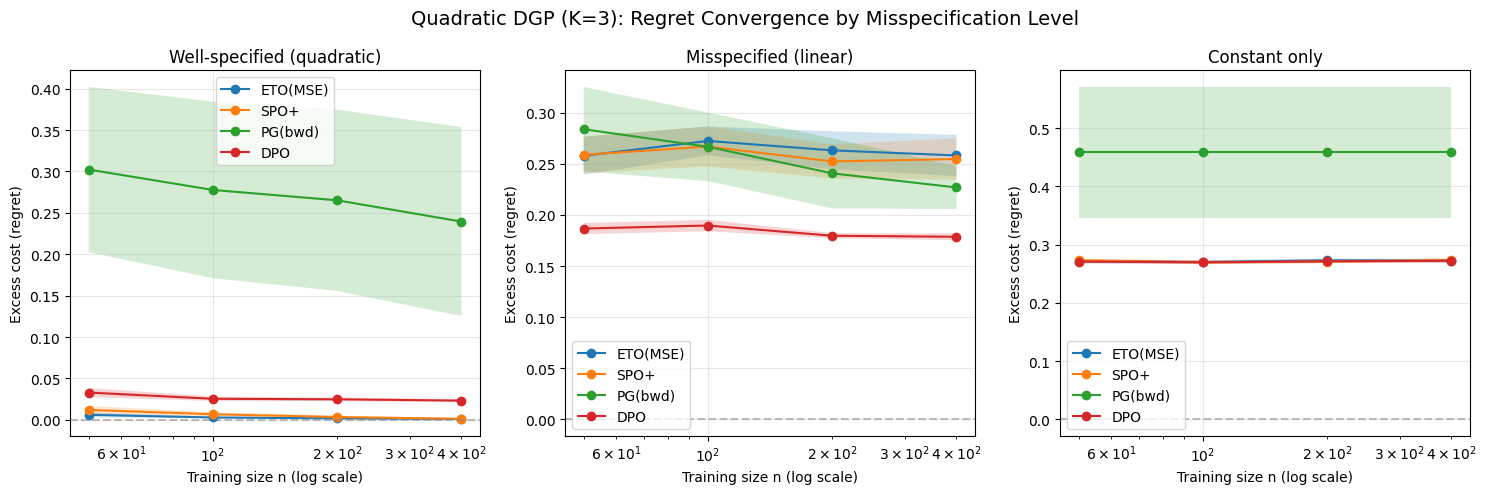


Key insights for Quadratic DGP:
- Well-specified (quadratic): regret → 0 as n increases
- Misspecified (linear): bounded regret floor (cannot capture curvature)
- Constant: large irreducible regret


In [4]:
# -----------------------
# 11b) Regret Convergence for Quadratic DGP
# -----------------------
print("\n" + "=" * 60)
print("REGRET CONVERGENCE: QUADRATIC DGP")
print("=" * 60)

ns_regret = [50, 100, 200, 400]
spec_levels_q = [0, 1, 2]
n_trials_regret = 20

results_quad = {}

for spec in spec_levels_q:
    for loss_name in LOSS_FNS.keys():
        curve = []
        print(f"Running: spec={spec} ({SPEC_NAMES_QUAD[spec]}), loss={loss_name}...")
        for n in ns_regret:
            regrets = []
            for trial in range(n_trials_regret):
                rng = np.random.default_rng(1000 + 17*trial + 100*spec + n)
                x_tr, z_tr = dgp_quad.sample(n, rng)
                model = fit_ieo_quad(
                    x_tr, z_tr, K=dgp_quad.K, spec_level=spec, loss_name=loss_name,
                    steps=1000, lr=2e-2, batch_size=128,
                    seed=2000 + 19*trial + 10*spec
                )
                reg = evaluate_regret(dgp_quad, model, n_test=5000, seed=5000 + trial)
                regrets.append(reg)
            curve.append((n, float(np.mean(regrets)), float(np.std(regrets))))
        results_quad[(spec, loss_name)] = curve

# -----------------------
# Plot: regret vs n for each misspec level (Quadratic DGP)
# -----------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, spec in enumerate(spec_levels_q):
    ax = axes[i]
    for loss_name in LOSS_FNS.keys():
        curve = results_quad[(spec, loss_name)]
        n_arr = np.array([c[0] for c in curve])
        mean = np.array([c[1] for c in curve])
        std = np.array([c[2] for c in curve])
        ax.plot(n_arr, mean, marker='o', label=loss_name)
        ax.fill_between(n_arr, mean - 1.96*std/np.sqrt(n_trials_regret), 
                        mean + 1.96*std/np.sqrt(n_trials_regret), alpha=0.2)
    ax.set_xscale("log")
    ax.axhline(0.0, linestyle="--", color='gray', alpha=0.5)
    ax.set_xlabel("Training size n (log scale)")
    ax.set_ylabel("Excess cost (regret)")
    ax.set_title(f"{SPEC_NAMES_QUAD[spec]}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Quadratic DGP (K=3): Regret Convergence by Misspecification Level", fontsize=14)
plt.tight_layout()
plt.show()

print("\nKey insights for Quadratic DGP:")
print("- Well-specified (quadratic): regret → 0 as n increases")
print("- Misspecified (linear): bounded regret floor (cannot capture curvature)")
print("- Constant: large irreducible regret")


ASYMPTOTIC CONVERGENCE: QUADRATIC DGP (LINEAR MISSPECIFIED)
Training oracle models with large n to approximate theta* for each loss (linear model)...
  SPO+: theta* computed (dim=9)
  PG(bwd): theta* computed (dim=9)
  DPO: theta* computed (dim=9)

Running trials for SPO+ (linear misspecified)...
  n=50... done
  n=100... done
  n=200... done
  n=400... done

Running trials for PG(bwd) (linear misspecified)...
  n=50... done
  n=100... done
  n=200... done
  n=400... done

Running trials for DPO (linear misspecified)...
  n=50... done
  n=100... done
  n=200... done
  n=400... done


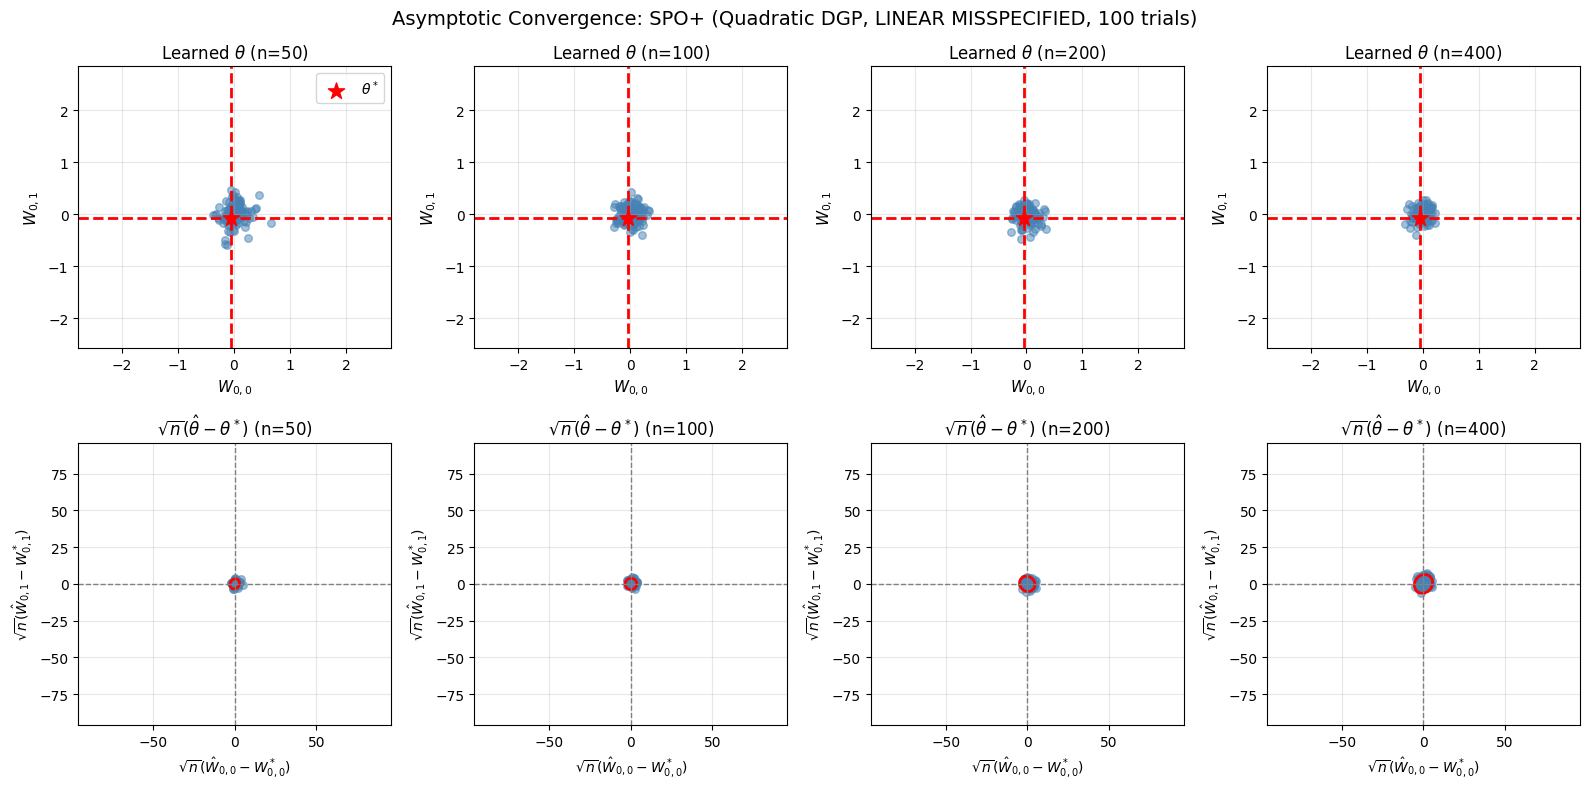

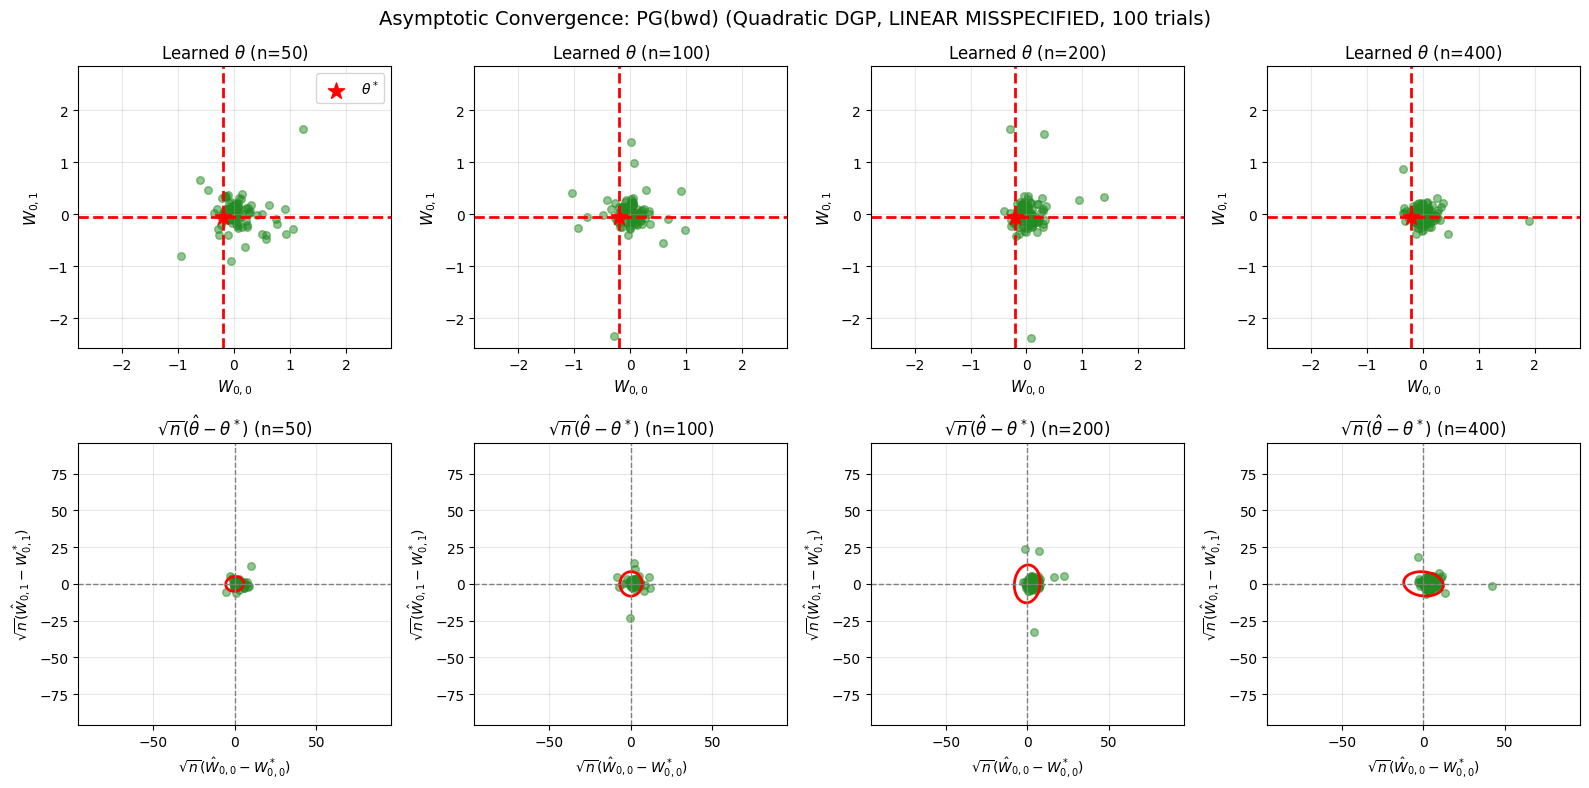

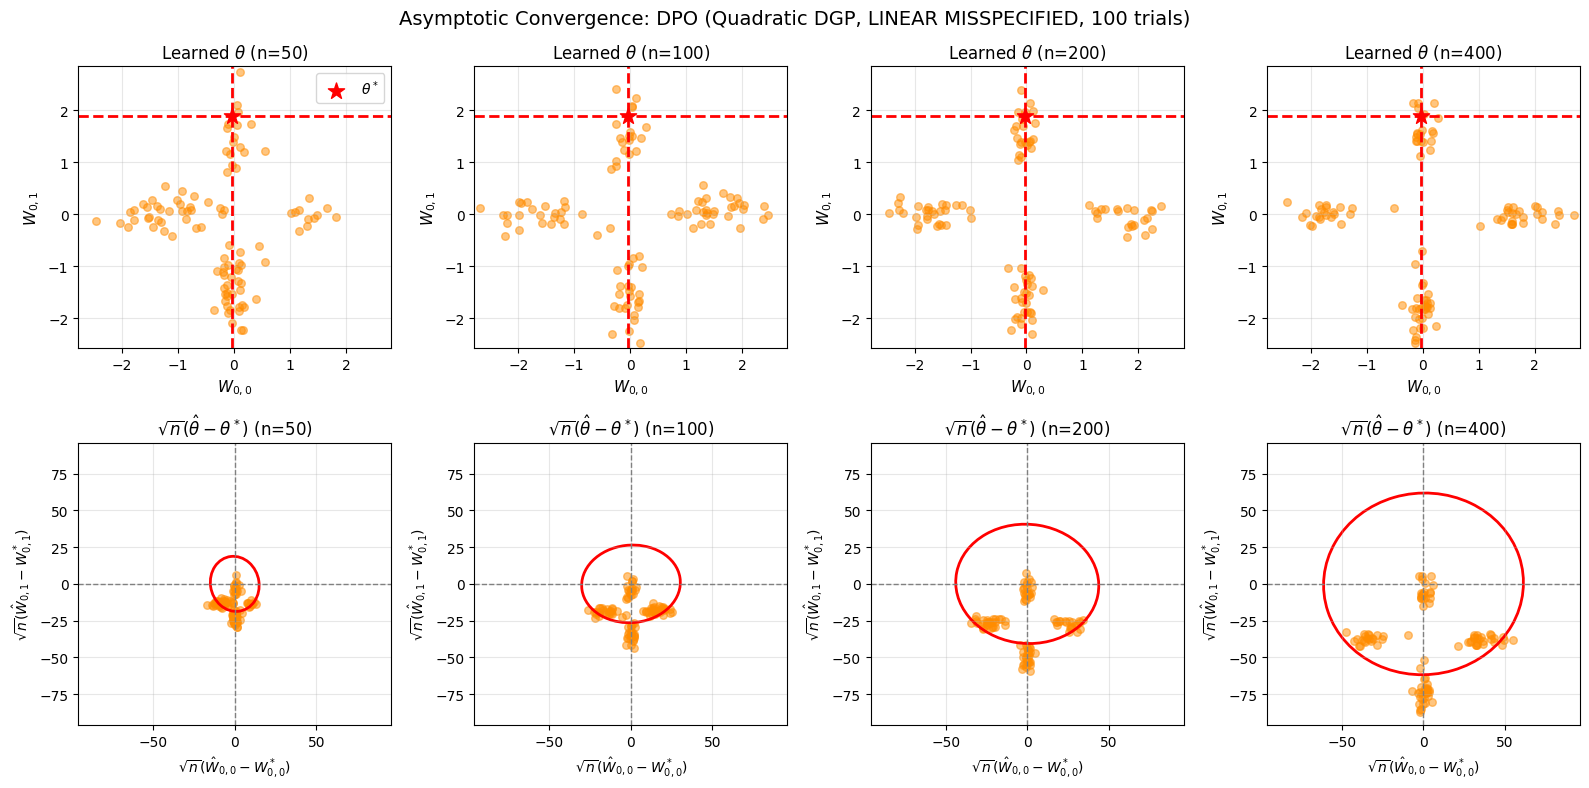

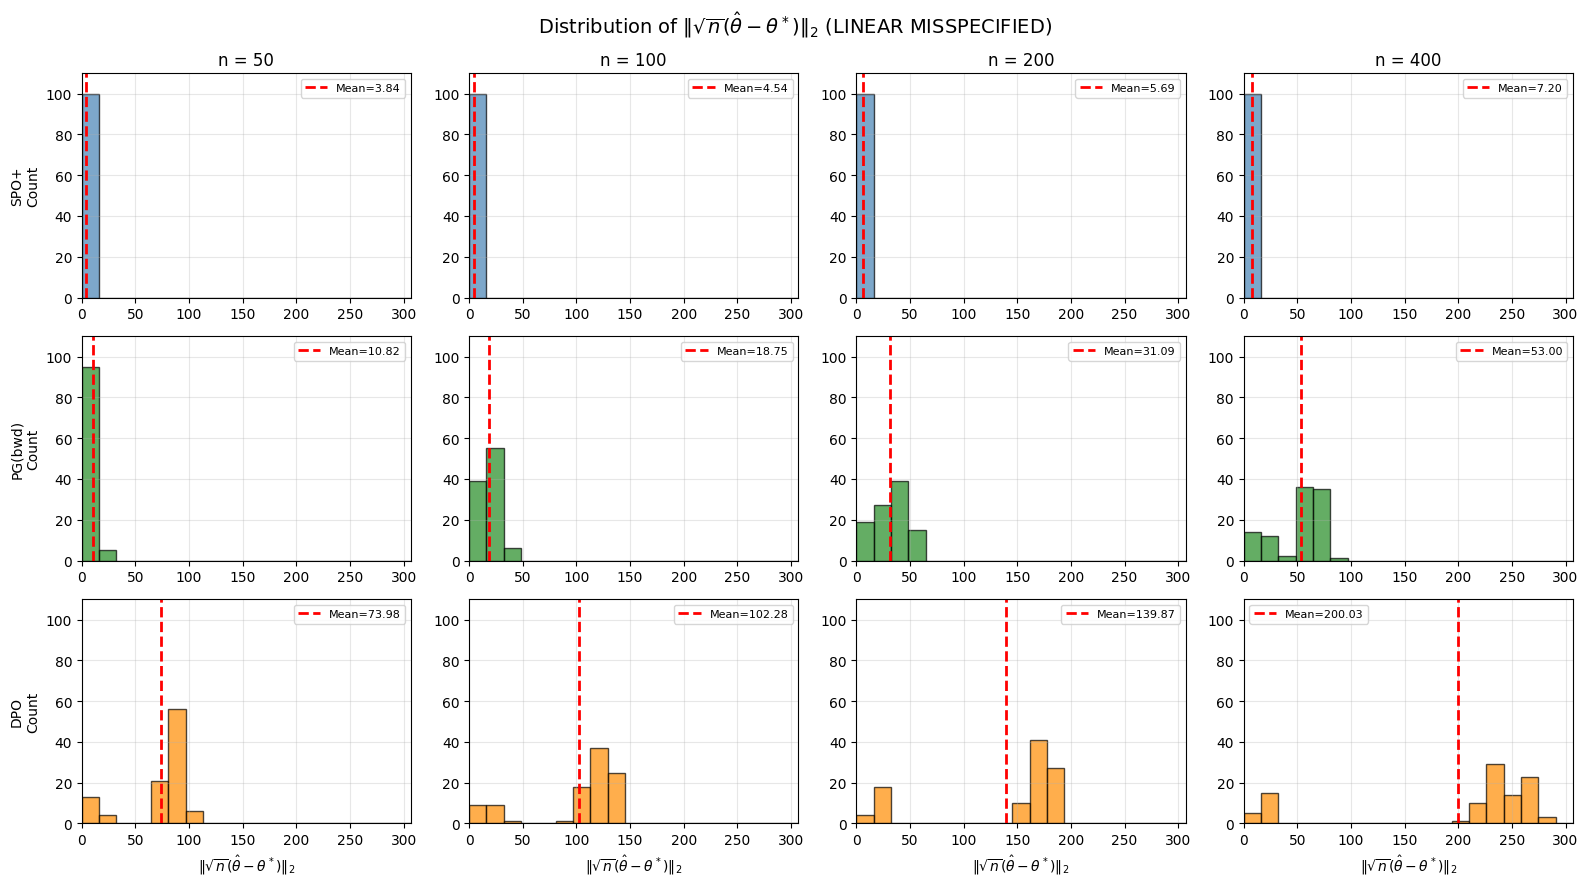

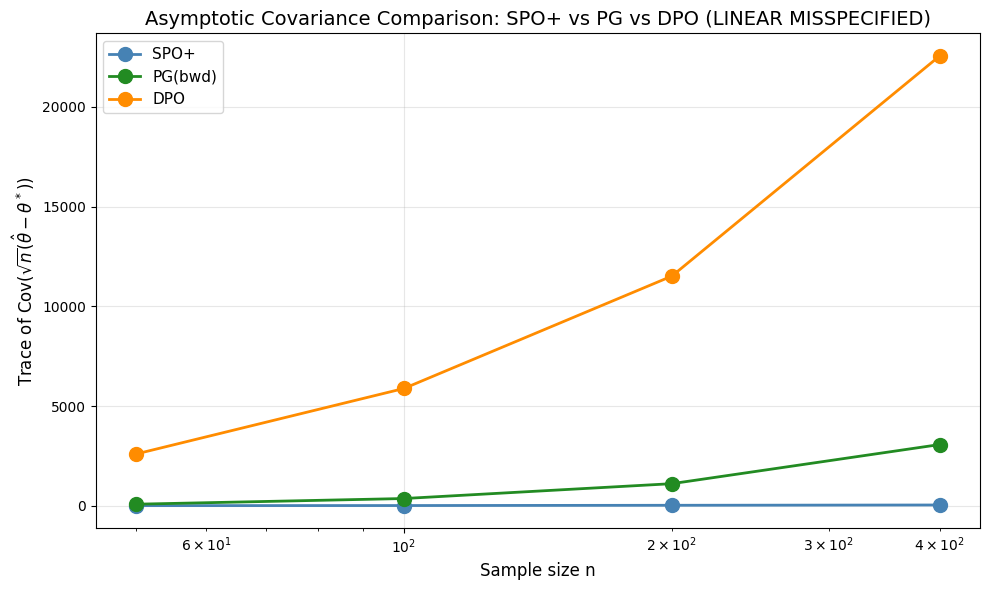


Key observations for LINEAR MISSPECIFICATION:
- θ* is now the best linear approximation (pseudo-true parameter)
- Even with misspecification, √n convergence may still hold
- Different losses may converge to different pseudo-true parameters


In [5]:
# -----------------------
# 11c) Asymptotic Convergence for Quadratic DGP: LINEAR MISSPECIFICATION
# -----------------------
print("\n" + "=" * 60)
print("ASYMPTOTIC CONVERGENCE: QUADRATIC DGP (LINEAR MISSPECIFIED)")
print("=" * 60)

# Train oracle model with large n for linear misspecification
print("Training oracle models with large n to approximate theta* for each loss (linear model)...")
n_oracle_mis = 10000
rng_oracle_mis = np.random.default_rng(888)
x_oracle_mis, z_oracle_mis = dgp_quad.sample(n_oracle_mis, rng_oracle_mis)

# Get theta* for each loss function under linear misspecification
loss_names_mis = ["SPO+", "PG(bwd)", "DPO"]
theta_star_mis = {}

for loss_name in loss_names_mis:
    model_oracle = fit_ieo_quad(x_oracle_mis, z_oracle_mis, K=dgp_quad.K, spec_level=1,  # linear misspecified
                                 loss_name=loss_name, steps=2000, lr=1e-2, seed=888)
    with torch.no_grad():
        theta_star_mis[loss_name] = torch.cat([model_oracle.W.flatten(), model_oracle.b]).cpu().numpy()
    print(f"  {loss_name}: theta* computed (dim={theta_star_mis[loss_name].shape[0]})")

# Run trials for each sample size and loss
ns_mis = [50, 100, 200, 400]
n_trials_mis = 100

# Store results by loss
results_mis = {loss_name: {'theta': {n: [] for n in ns_mis}, 
                           'sqrt_n_diff': {n: [] for n in ns_mis}} 
               for loss_name in loss_names_mis}

for loss_name in loss_names_mis:
    theta_star = theta_star_mis[loss_name]
    print(f"\nRunning trials for {loss_name} (linear misspecified)...")
    for n in ns_mis:
        print(f"  n={n}...", end=" ", flush=True)
        for trial in range(n_trials_mis):
            rng = np.random.default_rng(6000 + 31*trial + n)
            x_tr, z_tr = dgp_quad.sample(n, rng)
            model = fit_ieo_quad(x_tr, z_tr, K=dgp_quad.K, spec_level=1,  # linear misspecified
                                  loss_name=loss_name, steps=1000, lr=2e-2, seed=7000 + 37*trial + n)
            
            with torch.no_grad():
                theta_hat = torch.cat([model.W.flatten(), model.b]).cpu().numpy()
            
            results_mis[loss_name]['theta'][n].append(theta_hat)
            sqrt_n_diff = np.sqrt(n) * (theta_hat - theta_star)
            results_mis[loss_name]['sqrt_n_diff'][n].append(sqrt_n_diff)
        print("done")

# Convert to arrays
for loss_name in loss_names_mis:
    for n in ns_mis:
        results_mis[loss_name]['theta'][n] = np.array(results_mis[loss_name]['theta'][n])
        results_mis[loss_name]['sqrt_n_diff'][n] = np.array(results_mis[loss_name]['sqrt_n_diff'][n])

# -----------------------
# Compute shared axis limits for linear misspecification
# -----------------------
param_idx1_mis, param_idx2_mis = 0, 1  # First two params of W (linear model has W in R^(K x 2))

# Get global limits across all losses and sample sizes
all_theta_p1_mis = []
all_theta_p2_mis = []
all_diff_p1_mis = []
all_diff_p2_mis = []
all_norms_mis = []

for loss_name in loss_names_mis:
    theta_star = theta_star_mis[loss_name]
    for n in ns_mis:
        thetas = results_mis[loss_name]['theta'][n]
        diffs = results_mis[loss_name]['sqrt_n_diff'][n]
        all_theta_p1_mis.extend(thetas[:, param_idx1_mis])
        all_theta_p2_mis.extend(thetas[:, param_idx2_mis])
        all_diff_p1_mis.extend(diffs[:, param_idx1_mis])
        all_diff_p2_mis.extend(diffs[:, param_idx2_mis])
        all_norms_mis.extend(np.linalg.norm(diffs, axis=1))

all_theta_p1_mis = np.array(all_theta_p1_mis)
all_theta_p2_mis = np.array(all_theta_p2_mis)
all_diff_p1_mis = np.array(all_diff_p1_mis)
all_diff_p2_mis = np.array(all_diff_p2_mis)
all_norms_mis = np.array(all_norms_mis)

# Include theta_star values in limits
for loss_name in loss_names_mis:
    ts = theta_star_mis[loss_name]
    all_theta_p1_mis = np.append(all_theta_p1_mis, ts[param_idx1_mis])
    all_theta_p2_mis = np.append(all_theta_p2_mis, ts[param_idx2_mis])

theta_xlim_mis = (all_theta_p1_mis.min() - 0.1, all_theta_p1_mis.max() + 0.1)
theta_ylim_mis = (all_theta_p2_mis.min() - 0.1, all_theta_p2_mis.max() + 0.1)
diff_max_mis = max(np.abs(all_diff_p1_mis).max(), np.abs(all_diff_p2_mis).max()) * 1.1
diff_lim_mis = (-diff_max_mis, diff_max_mis)
hist_xlim_mis = (0, np.max(all_norms_mis) * 1.1)

# -----------------------
# Plot: One figure per loss function (Linear Misspecified)
# -----------------------
loss_colors = {"SPO+": "steelblue", "PG(bwd)": "forestgreen", "DPO": "darkorange"}

for loss_name in loss_names_mis:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    theta_star = theta_star_mis[loss_name]
    
    # Top row: learned theta distribution
    for i, n in enumerate(ns_mis):
        ax = axes[0, i]
        thetas = results_mis[loss_name]['theta'][n]
        ax.scatter(thetas[:, param_idx1_mis], thetas[:, param_idx2_mis], alpha=0.5, s=30, c=loss_colors[loss_name])
        ax.axvline(theta_star[param_idx1_mis], color='red', linestyle='--', linewidth=2)
        ax.axhline(theta_star[param_idx2_mis], color='red', linestyle='--', linewidth=2)
        ax.scatter([theta_star[param_idx1_mis]], [theta_star[param_idx2_mis]], color='red', s=150, marker='*', zorder=5, label='$\\theta^*$')
        ax.set_xlabel('$W_{0,0}$', fontsize=11)
        ax.set_ylabel('$W_{0,1}$', fontsize=11)
        ax.set_title(f'Learned $\\theta$ (n={n})', fontsize=12)
        ax.set_xlim(theta_xlim_mis)
        ax.set_ylim(theta_ylim_mis)
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend(loc='upper right')
    
    # Bottom row: sqrt(n)(theta - theta*) distribution
    from matplotlib.patches import Ellipse
    for i, n in enumerate(ns_mis):
        ax = axes[1, i]
        diffs = results_mis[loss_name]['sqrt_n_diff'][n]
        ax.scatter(diffs[:, param_idx1_mis], diffs[:, param_idx2_mis], alpha=0.5, s=30, c=loss_colors[loss_name])
        ax.axvline(0, color='gray', linestyle='--', linewidth=1)
        ax.axhline(0, color='gray', linestyle='--', linewidth=1)
        ax.set_xlabel(f'$\\sqrt{{n}}(\\hat{{W}}_{{0,0}} - W^*_{{0,0}})$', fontsize=10)
        ax.set_ylabel(f'$\\sqrt{{n}}(\\hat{{W}}_{{0,1}} - W^*_{{0,1}})$', fontsize=10)
        ax.set_title(f'$\\sqrt{{n}}(\\hat{{\\theta}} - \\theta^*)$ (n={n})', fontsize=12)
        ax.set_xlim(diff_lim_mis)
        ax.set_ylim(diff_lim_mis)
        ax.grid(True, alpha=0.3)
        
        # Add 95% confidence ellipse
        cov = np.cov(diffs[:, param_idx1_mis], diffs[:, param_idx2_mis])
        eigenvalues, eigenvectors = np.linalg.eig(cov)
        angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
        width, height = 2 * np.sqrt(5.991 * eigenvalues)
        ellipse = Ellipse(xy=(0, 0), width=width, height=height, angle=angle,
                          edgecolor='red', facecolor='none', linewidth=2)
        ax.add_patch(ellipse)
    
    plt.suptitle(f'Asymptotic Convergence: {loss_name} (Quadratic DGP, LINEAR MISSPECIFIED, {n_trials_mis} trials)', fontsize=14)
    plt.tight_layout()
    plt.show()

# -----------------------
# Histogram comparison across losses (Linear Misspecified)
# -----------------------
fig, axes = plt.subplots(len(loss_names_mis), 4, figsize=(16, 3*len(loss_names_mis)))

# Compute max count for consistent y-axis
max_count_mis = 0
bins_mis = np.linspace(hist_xlim_mis[0], hist_xlim_mis[1], 20)
for loss_name in loss_names_mis:
    for n in ns_mis:
        diffs = results_mis[loss_name]['sqrt_n_diff'][n]
        norms = np.linalg.norm(diffs, axis=1)
        counts, _ = np.histogram(norms, bins=bins_mis)
        max_count_mis = max(max_count_mis, counts.max())

for row, loss_name in enumerate(loss_names_mis):
    for col, n in enumerate(ns_mis):
        ax = axes[row, col]
        diffs = results_mis[loss_name]['sqrt_n_diff'][n]
        norms = np.linalg.norm(diffs, axis=1)
        
        ax.hist(norms, bins=bins_mis, alpha=0.7, color=loss_colors[loss_name], edgecolor='black')
        ax.axvline(np.mean(norms), color='red', linestyle='--', linewidth=2, label=f'Mean={np.mean(norms):.2f}')
        ax.set_xlim(hist_xlim_mis)
        ax.set_ylim(0, max_count_mis * 1.1)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
        
        if row == len(loss_names_mis) - 1:
            ax.set_xlabel('$\\|\\sqrt{n}(\\hat{\\theta} - \\theta^*)\\|_2$', fontsize=10)
        if col == 0:
            ax.set_ylabel(f'{loss_name}\nCount', fontsize=10)
        if row == 0:
            ax.set_title(f'n = {n}', fontsize=12)

plt.suptitle(f'Distribution of $\\|\\sqrt{{n}}(\\hat{{\\theta}} - \\theta^*)\\|_2$ (LINEAR MISSPECIFIED)', fontsize=14)
plt.tight_layout()
plt.show()

# -----------------------
# Compare covariance traces across losses (Linear Misspecified)
# -----------------------
fig, ax = plt.subplots(figsize=(10, 6))

for loss_name in loss_names_mis:
    cov_traces = []
    for n in ns_mis:
        diffs = results_mis[loss_name]['sqrt_n_diff'][n]
        cov = np.cov(diffs.T)
        cov_traces.append(np.trace(cov))
    ax.plot(ns_mis, cov_traces, 'o-', markersize=10, linewidth=2, 
            color=loss_colors[loss_name], label=loss_name)

ax.set_xlabel('Sample size n', fontsize=12)
ax.set_ylabel('Trace of Cov($\\sqrt{n}(\\hat{\\theta} - \\theta^*)$)', fontsize=12)
ax.set_title('Asymptotic Covariance Comparison: SPO+ vs PG vs DPO (LINEAR MISSPECIFIED)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xscale('log')

plt.tight_layout()
plt.show()

print("\nKey observations for LINEAR MISSPECIFICATION:")
print("- θ* is now the best linear approximation (pseudo-true parameter)")
print("- Even with misspecification, √n convergence may still hold")
print("- Different losses may converge to different pseudo-true parameters")


ASYMPTOTIC CONVERGENCE: QUADRATIC DGP (SPO+, PG, DPO)
Training oracle models with large n to approximate theta* for each loss...
  SPO+: theta* computed
  PG(bwd): theta* computed
  DPO: theta* computed

Running trials for SPO+...
  n=50... done
  n=100... done
  n=200... done
  n=400... done

Running trials for PG(bwd)...
  n=50... done
  n=100... done
  n=200... done
  n=400... done

Running trials for DPO...
  n=50... done
  n=100... done
  n=200... done
  n=400... done


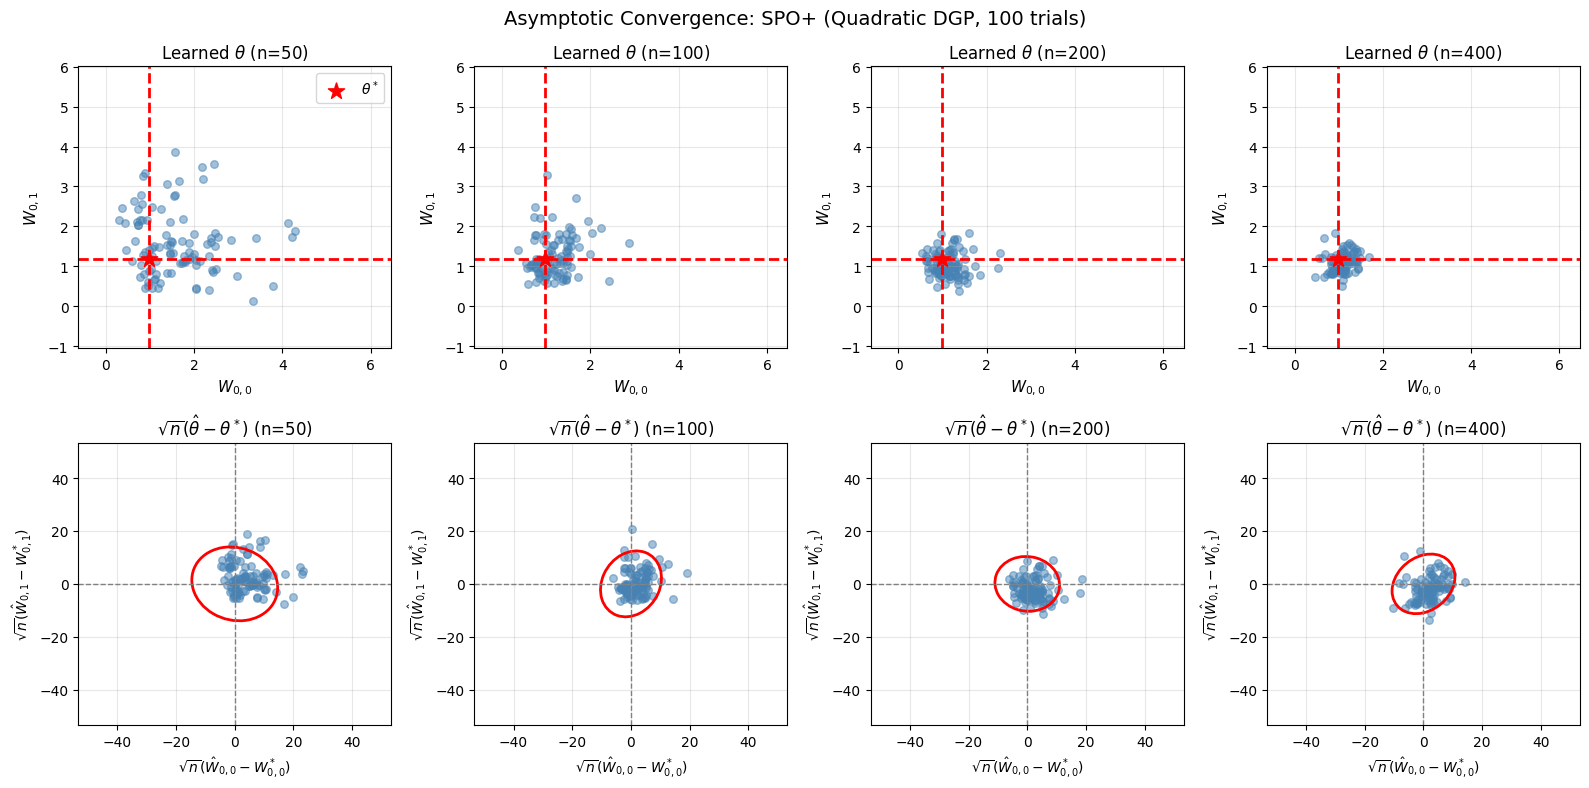

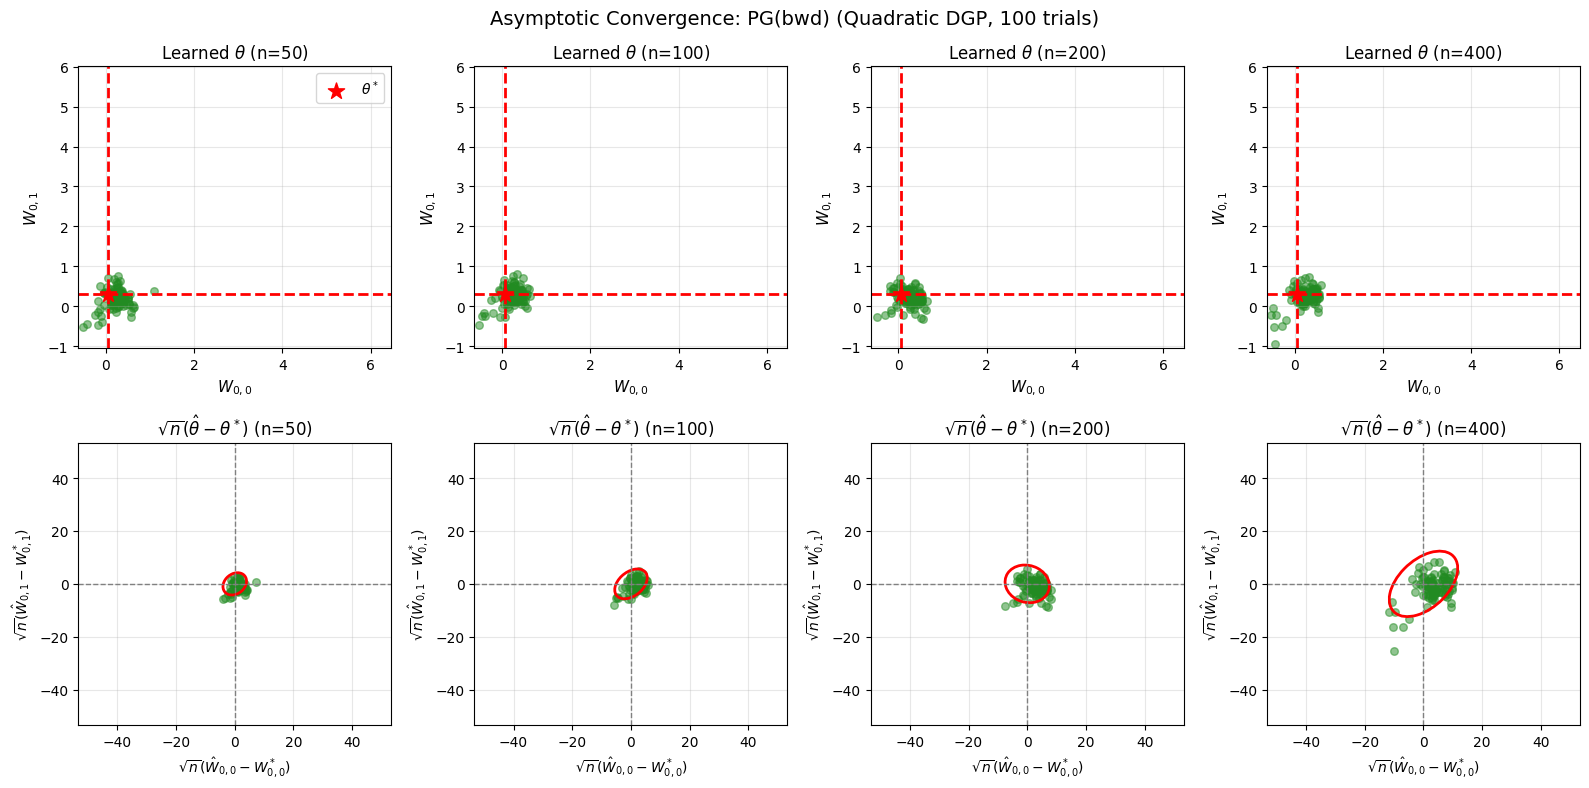

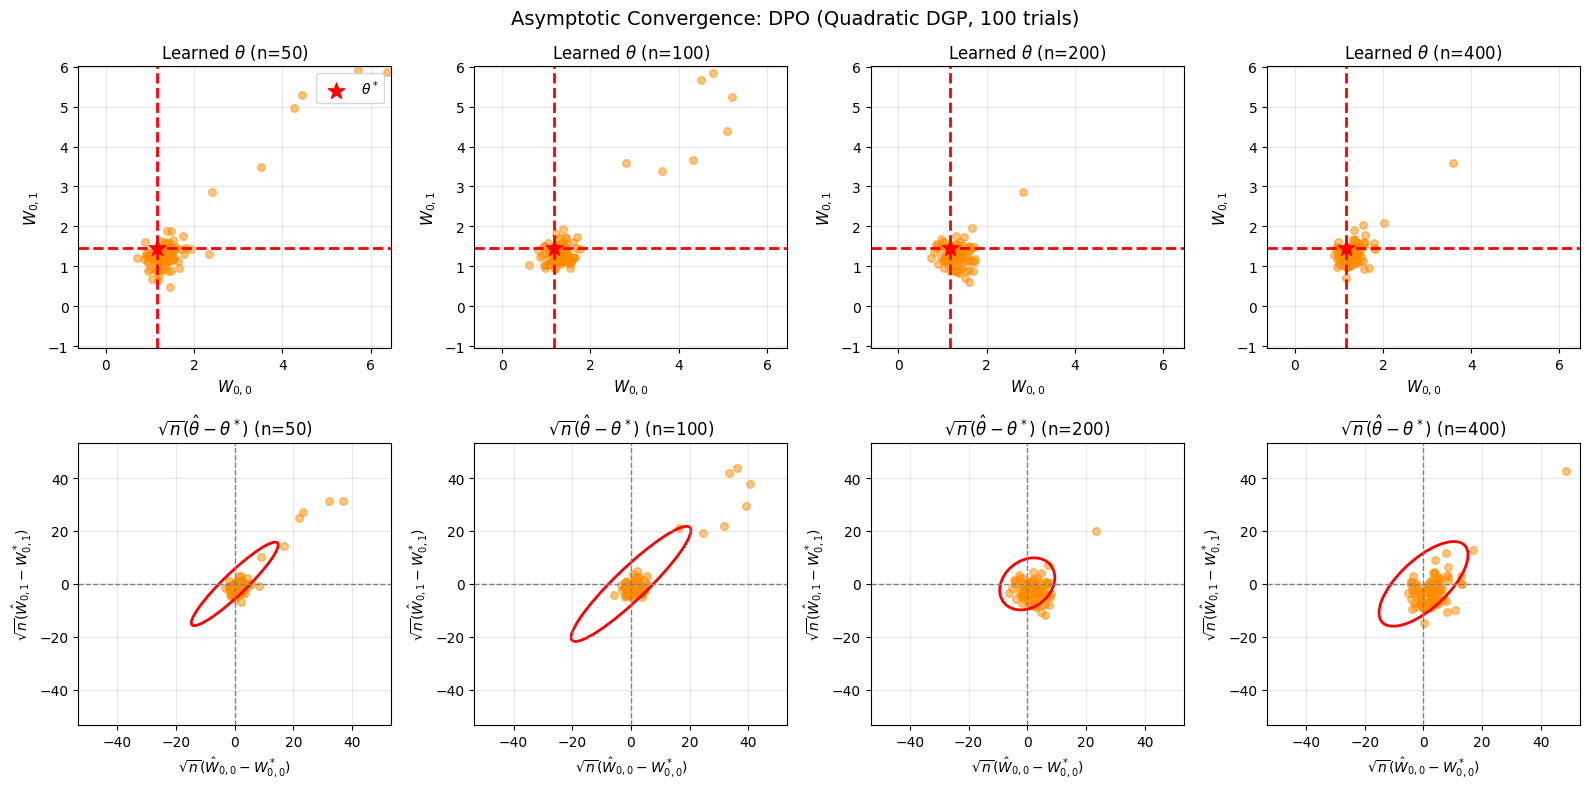

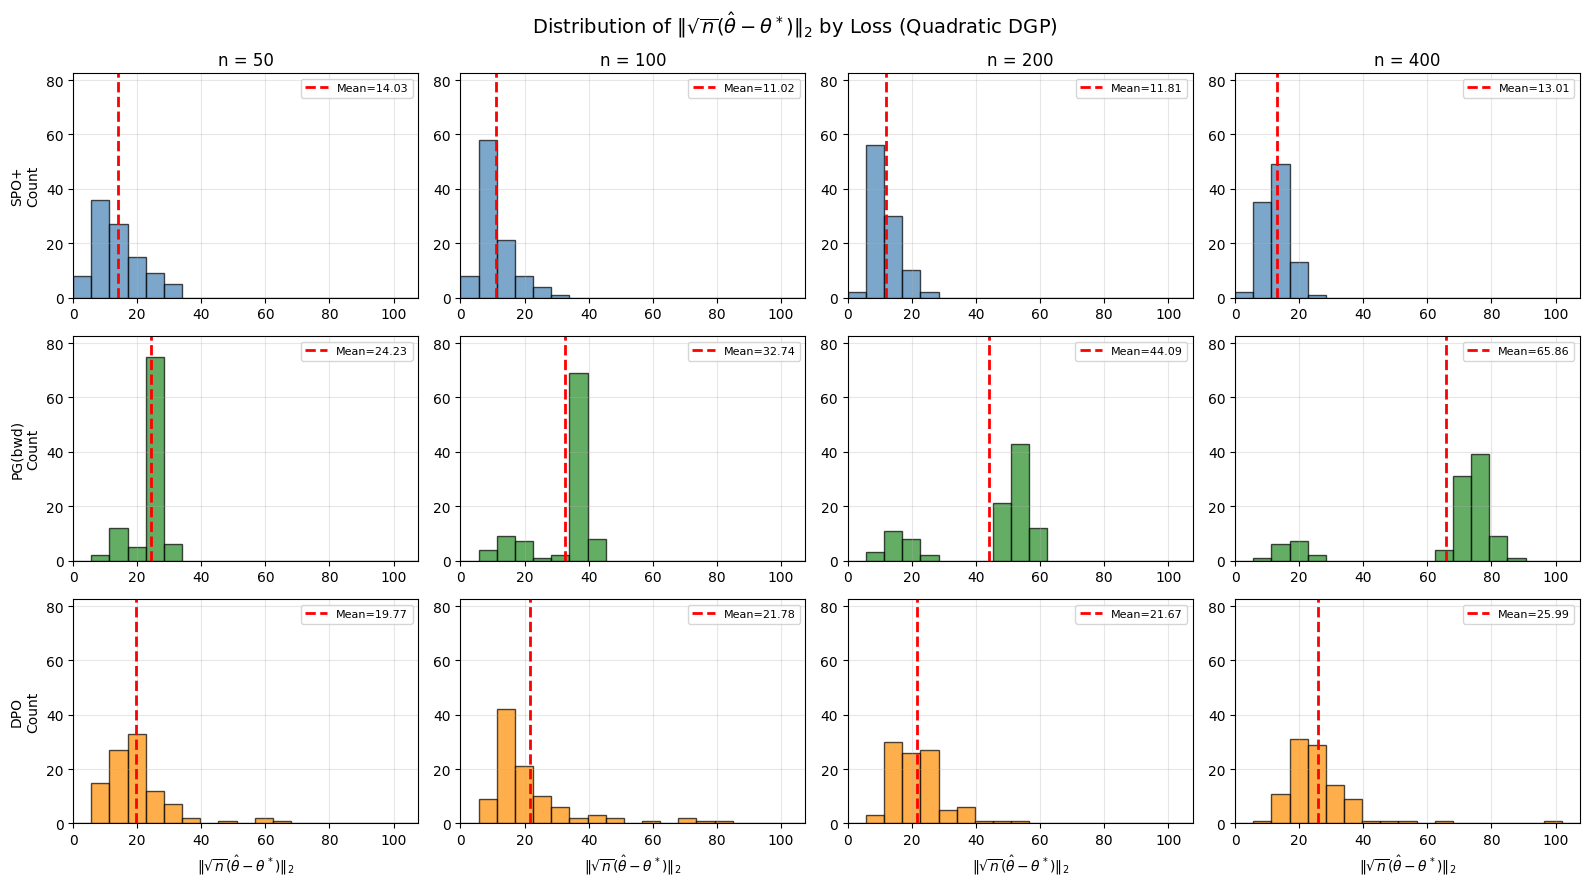

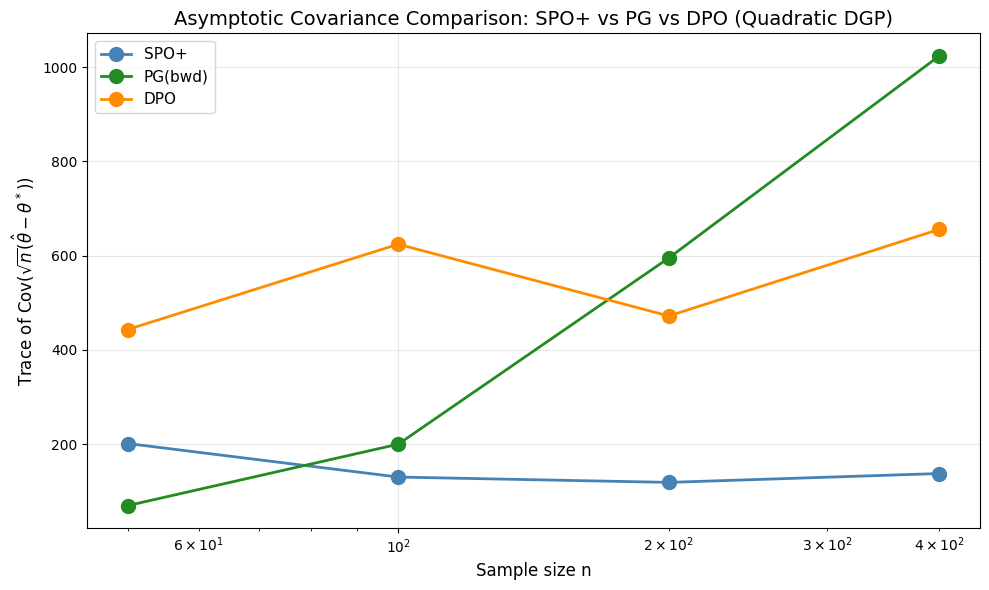


Key observations:
- All three losses show sqrt(n) convergence rate in the well-specified case
- Different losses may have different asymptotic covariance matrices
- Smaller covariance trace implies tighter concentration around theta*


In [6]:
# -----------------------
# 12) Asymptotic Convergence for Quadratic DGP: SPO+, PG, DPO
# -----------------------
print("\n" + "=" * 60)
print("ASYMPTOTIC CONVERGENCE: QUADRATIC DGP (SPO+, PG, DPO)")
print("=" * 60)

# Train oracle model with large n
print("Training oracle models with large n to approximate theta* for each loss...")
n_oracle = 10000
rng_oracle = np.random.default_rng(999)
x_oracle_q, z_oracle_q = dgp_quad.sample(n_oracle, rng_oracle)

# Get theta* for each loss function
loss_names_to_analyze = ["SPO+", "PG(bwd)", "DPO"]
theta_star_by_loss = {}

for loss_name in loss_names_to_analyze:
    model_oracle = fit_ieo_quad(x_oracle_q, z_oracle_q, K=dgp_quad.K, spec_level=0, 
                                 loss_name=loss_name, steps=2000, lr=1e-2, seed=999)
    with torch.no_grad():
        theta_star_by_loss[loss_name] = torch.cat([model_oracle.W.flatten(), model_oracle.b]).cpu().numpy()
    print(f"  {loss_name}: theta* computed")

# Run trials for each sample size and loss
ns_analysis_q = [50, 100, 200, 400]
n_trials_q = 100

# Store results by loss
results_by_loss = {loss_name: {'theta': {n: [] for n in ns_analysis_q}, 
                               'sqrt_n_diff': {n: [] for n in ns_analysis_q}} 
                   for loss_name in loss_names_to_analyze}

for loss_name in loss_names_to_analyze:
    theta_star = theta_star_by_loss[loss_name]
    print(f"\nRunning trials for {loss_name}...")
    for n in ns_analysis_q:
        print(f"  n={n}...", end=" ", flush=True)
        for trial in range(n_trials_q):
            rng = np.random.default_rng(3000 + 31*trial + n)
            x_tr, z_tr = dgp_quad.sample(n, rng)
            model = fit_ieo_quad(x_tr, z_tr, K=dgp_quad.K, spec_level=0, loss_name=loss_name,
                                  steps=1000, lr=2e-2, seed=4000 + 37*trial + n)
            
            with torch.no_grad():
                theta_hat = torch.cat([model.W.flatten(), model.b]).cpu().numpy()
            
            results_by_loss[loss_name]['theta'][n].append(theta_hat)
            sqrt_n_diff = np.sqrt(n) * (theta_hat - theta_star)
            results_by_loss[loss_name]['sqrt_n_diff'][n].append(sqrt_n_diff)
        print("done")

# Convert to arrays
for loss_name in loss_names_to_analyze:
    for n in ns_analysis_q:
        results_by_loss[loss_name]['theta'][n] = np.array(results_by_loss[loss_name]['theta'][n])
        results_by_loss[loss_name]['sqrt_n_diff'][n] = np.array(results_by_loss[loss_name]['sqrt_n_diff'][n])

# -----------------------
# Compute shared axis limits
# -----------------------
param_idx1, param_idx2 = 0, 1  # First two params of W

# Get global limits across all losses and sample sizes
all_theta_p1 = []
all_theta_p2 = []
all_diff_p1 = []
all_diff_p2 = []
all_norms = []

for loss_name in loss_names_to_analyze:
    theta_star = theta_star_by_loss[loss_name]
    for n in ns_analysis_q:
        thetas = results_by_loss[loss_name]['theta'][n]
        diffs = results_by_loss[loss_name]['sqrt_n_diff'][n]
        all_theta_p1.extend(thetas[:, param_idx1])
        all_theta_p2.extend(thetas[:, param_idx2])
        all_diff_p1.extend(diffs[:, param_idx1])
        all_diff_p2.extend(diffs[:, param_idx2])
        all_norms.extend(np.linalg.norm(diffs, axis=1))

all_theta_p1 = np.array(all_theta_p1)
all_theta_p2 = np.array(all_theta_p2)
all_diff_p1 = np.array(all_diff_p1)
all_diff_p2 = np.array(all_diff_p2)
all_norms = np.array(all_norms)

# Include theta_star values in limits
for loss_name in loss_names_to_analyze:
    ts = theta_star_by_loss[loss_name]
    all_theta_p1 = np.append(all_theta_p1, ts[param_idx1])
    all_theta_p2 = np.append(all_theta_p2, ts[param_idx2])

theta_xlim_q = (all_theta_p1.min() - 0.1, all_theta_p1.max() + 0.1)
theta_ylim_q = (all_theta_p2.min() - 0.1, all_theta_p2.max() + 0.1)
diff_max_q = max(np.abs(all_diff_p1).max(), np.abs(all_diff_p2).max()) * 1.1
diff_lim_q = (-diff_max_q, diff_max_q)
hist_xlim_q = (0, np.max(all_norms) * 1.1)

# -----------------------
# Plot: One figure per loss function
# -----------------------
loss_colors = {"SPO+": "steelblue", "PG(bwd)": "forestgreen", "DPO": "darkorange"}

for loss_name in loss_names_to_analyze:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    theta_star = theta_star_by_loss[loss_name]
    
    # Top row: learned theta distribution
    for i, n in enumerate(ns_analysis_q):
        ax = axes[0, i]
        thetas = results_by_loss[loss_name]['theta'][n]
        ax.scatter(thetas[:, param_idx1], thetas[:, param_idx2], alpha=0.5, s=30, c=loss_colors[loss_name])
        ax.axvline(theta_star[param_idx1], color='red', linestyle='--', linewidth=2)
        ax.axhline(theta_star[param_idx2], color='red', linestyle='--', linewidth=2)
        ax.scatter([theta_star[param_idx1]], [theta_star[param_idx2]], color='red', s=150, marker='*', zorder=5, label='$\\theta^*$')
        ax.set_xlabel('$W_{0,0}$', fontsize=11)
        ax.set_ylabel('$W_{0,1}$', fontsize=11)
        ax.set_title(f'Learned $\\theta$ (n={n})', fontsize=12)
        ax.set_xlim(theta_xlim_q)
        ax.set_ylim(theta_ylim_q)
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend(loc='upper right')
    
    # Bottom row: sqrt(n)(theta - theta*) distribution
    from matplotlib.patches import Ellipse
    for i, n in enumerate(ns_analysis_q):
        ax = axes[1, i]
        diffs = results_by_loss[loss_name]['sqrt_n_diff'][n]
        ax.scatter(diffs[:, param_idx1], diffs[:, param_idx2], alpha=0.5, s=30, c=loss_colors[loss_name])
        ax.axvline(0, color='gray', linestyle='--', linewidth=1)
        ax.axhline(0, color='gray', linestyle='--', linewidth=1)
        ax.set_xlabel(f'$\\sqrt{{n}}(\\hat{{W}}_{{0,0}} - W^*_{{0,0}})$', fontsize=10)
        ax.set_ylabel(f'$\\sqrt{{n}}(\\hat{{W}}_{{0,1}} - W^*_{{0,1}})$', fontsize=10)
        ax.set_title(f'$\\sqrt{{n}}(\\hat{{\\theta}} - \\theta^*)$ (n={n})', fontsize=12)
        ax.set_xlim(diff_lim_q)
        ax.set_ylim(diff_lim_q)
        ax.grid(True, alpha=0.3)
        
        # Add 95% confidence ellipse
        cov = np.cov(diffs[:, param_idx1], diffs[:, param_idx2])
        eigenvalues, eigenvectors = np.linalg.eig(cov)
        angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
        width, height = 2 * np.sqrt(5.991 * eigenvalues)
        ellipse = Ellipse(xy=(0, 0), width=width, height=height, angle=angle,
                          edgecolor='red', facecolor='none', linewidth=2)
        ax.add_patch(ellipse)
    
    plt.suptitle(f'Asymptotic Convergence: {loss_name} (Quadratic DGP, {n_trials_q} trials)', fontsize=14)
    plt.tight_layout()
    plt.show()

# -----------------------
# Histogram comparison across losses
# -----------------------
fig, axes = plt.subplots(len(loss_names_to_analyze), 4, figsize=(16, 3*len(loss_names_to_analyze)))

# Compute max count for consistent y-axis
max_count_q = 0
bins_q = np.linspace(hist_xlim_q[0], hist_xlim_q[1], 20)
for loss_name in loss_names_to_analyze:
    for n in ns_analysis_q:
        diffs = results_by_loss[loss_name]['sqrt_n_diff'][n]
        norms = np.linalg.norm(diffs, axis=1)
        counts, _ = np.histogram(norms, bins=bins_q)
        max_count_q = max(max_count_q, counts.max())

for row, loss_name in enumerate(loss_names_to_analyze):
    for col, n in enumerate(ns_analysis_q):
        ax = axes[row, col]
        diffs = results_by_loss[loss_name]['sqrt_n_diff'][n]
        norms = np.linalg.norm(diffs, axis=1)
        
        ax.hist(norms, bins=bins_q, alpha=0.7, color=loss_colors[loss_name], edgecolor='black')
        ax.axvline(np.mean(norms), color='red', linestyle='--', linewidth=2, label=f'Mean={np.mean(norms):.2f}')
        ax.set_xlim(hist_xlim_q)
        ax.set_ylim(0, max_count_q * 1.1)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
        
        if row == len(loss_names_to_analyze) - 1:
            ax.set_xlabel('$\\|\\sqrt{n}(\\hat{\\theta} - \\theta^*)\\|_2$', fontsize=10)
        if col == 0:
            ax.set_ylabel(f'{loss_name}\nCount', fontsize=10)
        if row == 0:
            ax.set_title(f'n = {n}', fontsize=12)

plt.suptitle(f'Distribution of $\\|\\sqrt{{n}}(\\hat{{\\theta}} - \\theta^*)\\|_2$ by Loss (Quadratic DGP)', fontsize=14)
plt.tight_layout()
plt.show()

# -----------------------
# Compare covariance traces across losses
# -----------------------
fig, ax = plt.subplots(figsize=(10, 6))

for loss_name in loss_names_to_analyze:
    cov_traces = []
    for n in ns_analysis_q:
        diffs = results_by_loss[loss_name]['sqrt_n_diff'][n]
        cov = np.cov(diffs.T)
        cov_traces.append(np.trace(cov))
    ax.plot(ns_analysis_q, cov_traces, 'o-', markersize=10, linewidth=2, 
            color=loss_colors[loss_name], label=loss_name)

ax.set_xlabel('Sample size n', fontsize=12)
ax.set_ylabel('Trace of Cov($\\sqrt{n}(\\hat{\\theta} - \\theta^*)$)', fontsize=12)
ax.set_title('Asymptotic Covariance Comparison: SPO+ vs PG vs DPO (Quadratic DGP)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xscale('log')

plt.tight_layout()
plt.show()

print("\nKey observations:")
print("- All three losses show sqrt(n) convergence rate in the well-specified case")
print("- Different losses may have different asymptotic covariance matrices")
print("- Smaller covariance trace implies tighter concentration around theta*")